# 🏥 Sistem Prediksi Diabetes Berbasis Machine Learning
## Random Forest + Explainable AI (SHAP & LIME)

**Pipeline Lengkap:**
1. **TAHAP 1 (INPUT):** Load dataset & Exploratory Data Analysis
2. **TAHAP 2 (PROSES):** Preprocessing, SMOTE, Pemodelan Random Forest + Hyperparameter Tuning
3. **TAHAP 3 (OUTPUT):** Evaluasi, **Threshold Tuning**, XAI (SHAP & LIME), Sistem Prediksi Akhir

**Dataset:** Kaggle Diabetes Prediction Dataset (100K+ records)
**Fitur:** Glukosa, HbA1c, BMI, Usia, Hipertensi, Penyakit Jantung, Riwayat Merokok, Jenis Kelamin

**Catatan Penting:**
- Model dioptimasi untuk **RECALL** (sensitivitas) karena konteks medis:
  False Negative (pasien diabetes gagal terdeteksi) jauh lebih berbahaya daripada False Positive.
- **Threshold Tuning** menggunakan Youden's J Statistic untuk menemukan titik optimal
  antara sensitivitas dan spesifisitas pada kurva ROC.


---
## ⚙️ Instalasi & Import Library


In [1]:
# ============================================================
# CELL 1: Instalasi Library yang Dibutuhkan
# ============================================================
!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap lime kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc
)

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE

# Explainable AI
import shap
import lime
import lime.lime_tabular

warnings.filterwarnings('ignore')

# Konfigurasi visual global
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print("✅ Semua library berhasil di-import!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ Semua library berhasil di-import!


---
# 📥 TAHAP 1: INPUT — Load Data & Exploratory Data Analysis (EDA)


In [2]:
# ============================================================
# CELL 2: Load Dataset dari Kaggle
# ============================================================
import kagglehub

# Download dataset Kaggle Diabetes Prediction
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")
csv_file = os.path.join(path, "diabetes_prediction_dataset.csv")

df = pd.read_csv(csv_file)

# Pemetaan nama kolom ke Bahasa Indonesia untuk kejelasan
column_mapping = {
    'gender': 'Jenis_Kelamin',
    'age': 'Usia',
    'hypertension': 'Hipertensi',
    'heart_disease': 'Penyakit_Jantung',
    'smoking_history': 'Riwayat_Merokok',
    'bmi': 'BMI',
    'HbA1c_level': 'HbA1c',
    'blood_glucose_level': 'Kadar_Glukosa',
    'diabetes': 'Diabetes'
}
df.rename(columns=column_mapping, inplace=True)

print(f"📊 Dataset berhasil dimuat!")
print(f"   Jumlah Data : {df.shape[0]:,} baris")
print(f"   Jumlah Fitur: {df.shape[1]} kolom")
print(f"\n📋 Kolom Dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col} ({df[col].dtype})")

Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
📊 Dataset berhasil dimuat!
   Jumlah Data : 100,000 baris
   Jumlah Fitur: 9 kolom

📋 Kolom Dataset:
   1. Jenis_Kelamin (object)
   2. Usia (float64)
   3. Hipertensi (int64)
   4. Penyakit_Jantung (int64)
   5. Riwayat_Merokok (object)
   6. BMI (float64)
   7. HbA1c (float64)
   8. Kadar_Glukosa (int64)
   9. Diabetes (int64)


In [3]:
# ============================================================
# CELL 3: Ringkasan Statistik Dataset
# ============================================================
print("=" * 70)
print("📊 RINGKASAN STATISTIK DATASET")
print("=" * 70)

print("\n🔢 5 Baris Pertama:")
display(df.head())

print("\n📈 Deskripsi Statistik (Fitur Numerik):")
display(df.describe().round(2))

print("\n❓ Cek Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ Tidak ada missing values!")
else:
    display(missing[missing > 0])

print("\n📋 Info Tipe Data:")
display(df.dtypes)

print(f"\n🔍 Jumlah Duplikat: {df.duplicated().sum():,} baris")
# Hapus duplikat jika ada
df.drop_duplicates(inplace=True)
print(f"   Dataset setelah hapus duplikat: {df.shape[0]:,} baris")

📊 RINGKASAN STATISTIK DATASET

🔢 5 Baris Pertama:


,Jenis_Kelamin,Usia,Hipertensi,Penyakit_Jantung,Riwayat_Merokok,BMI,HbA1c,Kadar_Glukosa,Diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



📈 Deskripsi Statistik (Fitur Numerik):


,Usia,Hipertensi,Penyakit_Jantung,BMI,HbA1c,Kadar_Glukosa,Diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.89,0.07,0.04,27.32,5.53,138.06,0.08
std,22.52,0.26,0.19,6.64,1.07,40.71,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.63,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,60.00,0.00,0.00,29.58,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00



❓ Cek Missing Values:
   ✅ Tidak ada missing values!

📋 Info Tipe Data:


,0
Jenis_Kelamin,object
Usia,float64
Hipertensi,int64
Penyakit_Jantung,int64
Riwayat_Merokok,object
BMI,float64
HbA1c,float64
Kadar_Glukosa,int64
Diabetes,int64



🔍 Jumlah Duplikat: 3,854 baris
   Dataset setelah hapus duplikat: 96,146 baris


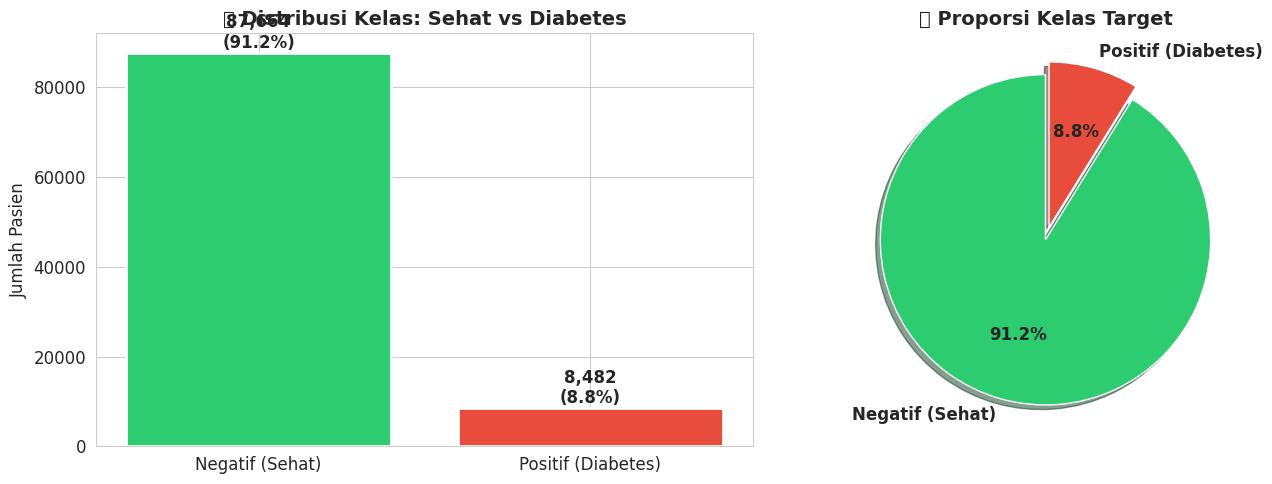


⚠️ Rasio Imbalance: 87,664 Sehat vs 8,482 Diabetes
   Rasio ≈ 10.3 : 1 — Dataset SANGAT TIMPANG → perlu SMOTE!


In [4]:
# ============================================================
# CELL 4: EDA — Visualisasi Distribusi Kelas Target (Diabetes)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
class_counts = df['Diabetes'].value_counts()
colors = ['#2ecc71', '#e74c3c']
labels = ['Negatif (Sehat)', 'Positif (Diabetes)']

bars = axes[0].bar(labels, class_counts.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('📊 Distribusi Kelas: Sehat vs Diabetes', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien')

# Tambahkan label di atas bar
for bar, count in zip(bars, class_counts.values):
    pct = count / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
                 f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Pie Chart
axes[1].pie(class_counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0, 0.08), shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('📊 Proporsi Kelas Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = class_counts[0] / class_counts[1]
print(f"\n⚠️ Rasio Imbalance: {class_counts[0]:,} Sehat vs {class_counts[1]:,} Diabetes")
print(f"   Rasio ≈ {ratio:.1f} : 1 — Dataset SANGAT TIMPANG → perlu SMOTE!")

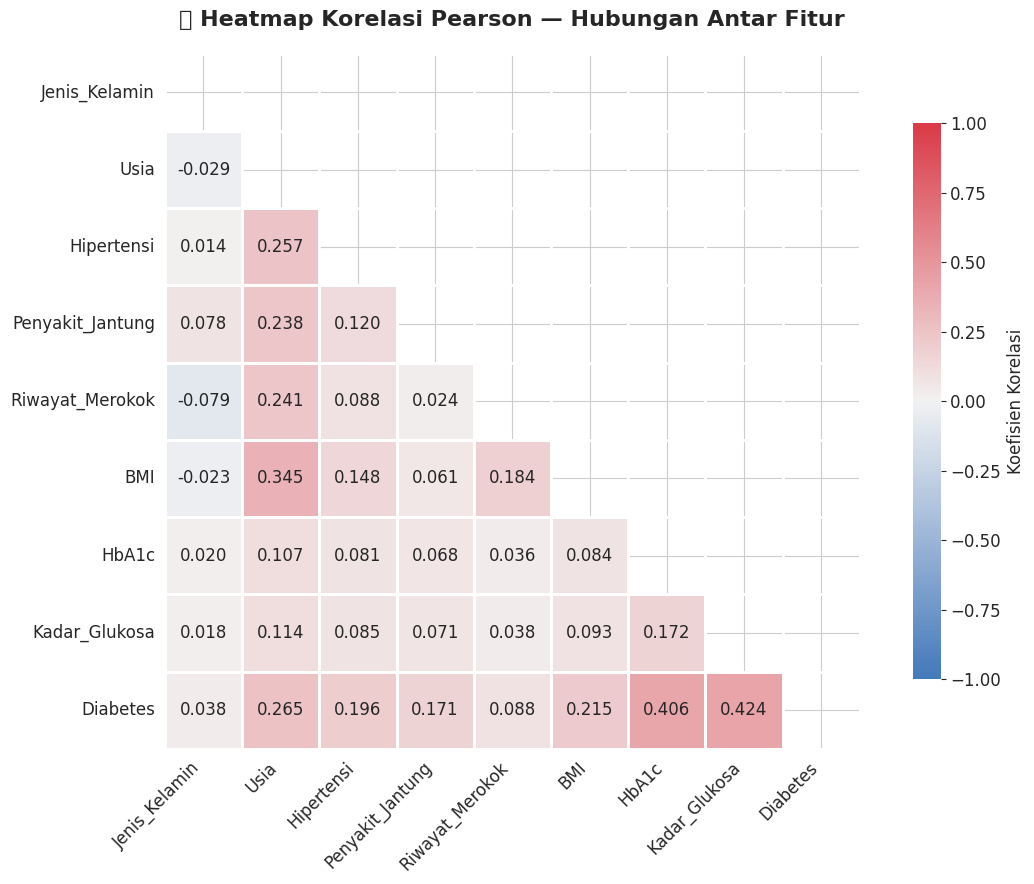


📊 Korelasi Fitur terhadap Target (Diabetes):
   Kadar_Glukosa        +0.4243  █████████████████████
   HbA1c                +0.4064  ████████████████████
   Usia                 +0.2649  █████████████
   BMI                  +0.2149  ██████████
   Hipertensi           +0.1957  █████████
   Penyakit_Jantung     +0.1707  ████████
   Riwayat_Merokok      +0.0885  ████
   Jenis_Kelamin        +0.0376  █


In [5]:
# ============================================================
# CELL 5: EDA — Heatmap Korelasi (Pearson Correlation)
# ============================================================
# Encode kolom kategorikal sementara untuk korelasi
df_corr = df.copy()
le_temp = LabelEncoder()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = le_temp.fit_transform(df_corr[col])

# Hitung Korelasi Pearson
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(250, 10, as_cmap=True)

heatmap = sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.3f',
    cmap=cmap, center=0, square=True, linewidths=1,
    cbar_kws={"shrink": 0.8, "label": "Koefisien Korelasi"},
    vmin=-1, vmax=1, ax=ax
)

ax.set_title('🔥 Heatmap Korelasi Pearson — Hubungan Antar Fitur', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Tampilkan korelasi terhadap target Diabetes
print("\n📊 Korelasi Fitur terhadap Target (Diabetes):")
print("=" * 50)
target_corr = corr_matrix['Diabetes'].drop('Diabetes').sort_values(ascending=False)
for feat, val in target_corr.items():
    bar = '█' * int(abs(val) * 50)
    sign = '+' if val > 0 else '-'
    print(f"   {feat:<20} {sign}{abs(val):.4f}  {bar}")

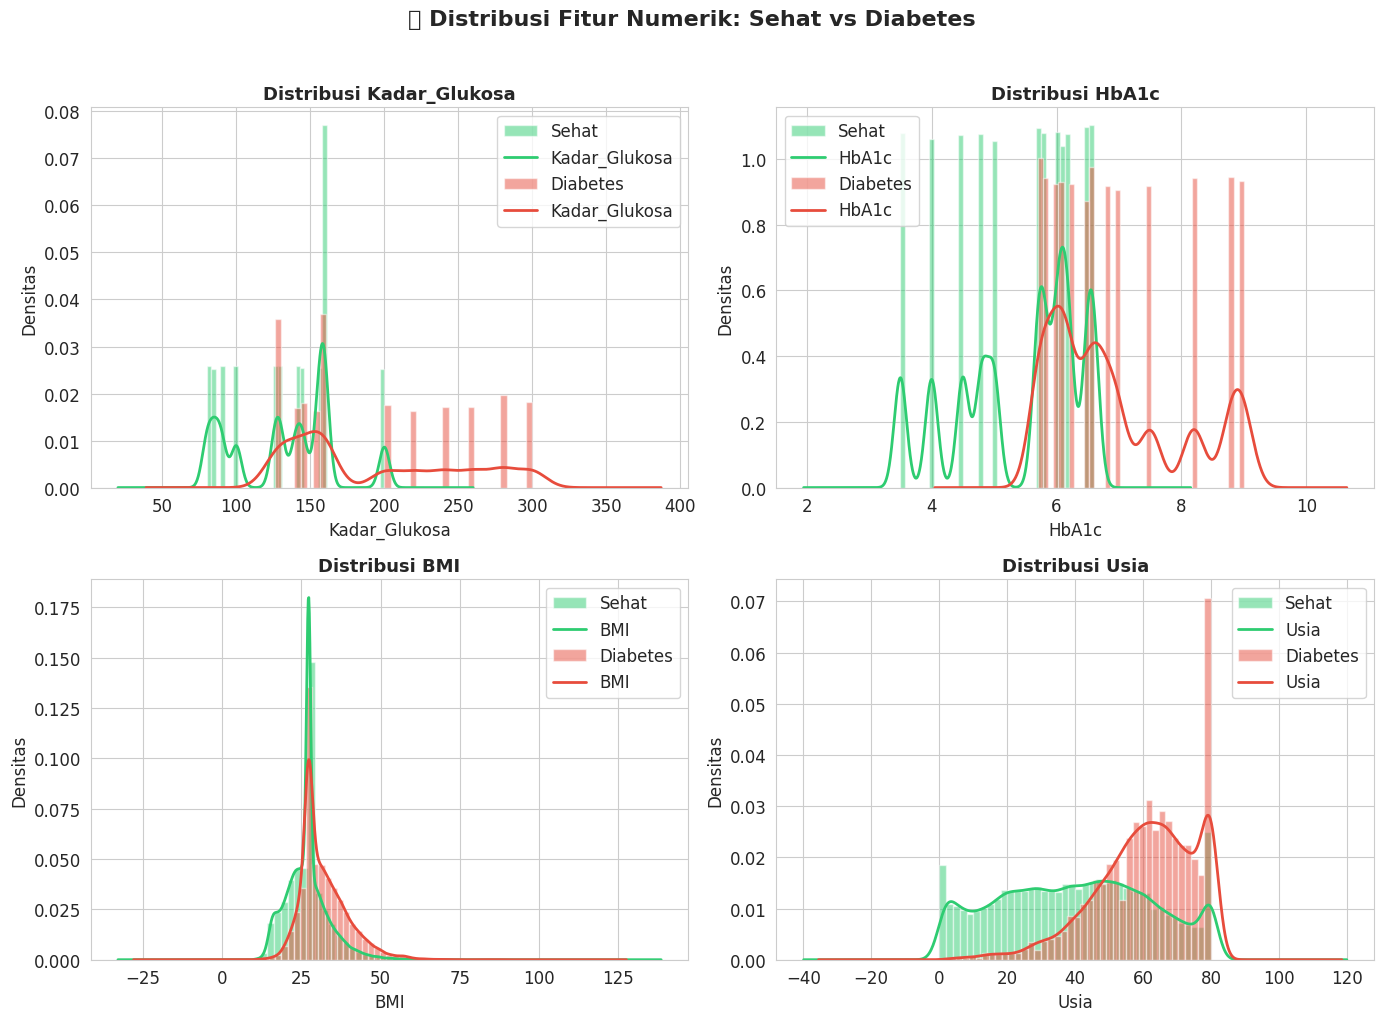

In [6]:
# ============================================================
# CELL 6: EDA — Distribusi Fitur Numerik berdasarkan Status Diabetes
# ============================================================
numeric_features = ['Kadar_Glukosa', 'HbA1c', 'BMI', 'Usia']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(numeric_features):
    # Histogram + KDE
    for label, color, name in [(0, '#2ecc71', 'Sehat'), (1, '#e74c3c', 'Diabetes')]:
        subset = df[df['Diabetes'] == label][feat]
        axes[idx].hist(subset, bins=40, alpha=0.5, color=color, label=name, density=True)
        subset.plot.kde(ax=axes[idx], color=color, linewidth=2)

    axes[idx].set_title(f'Distribusi {feat}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Densitas')
    axes[idx].legend()

plt.suptitle('📊 Distribusi Fitur Numerik: Sehat vs Diabetes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

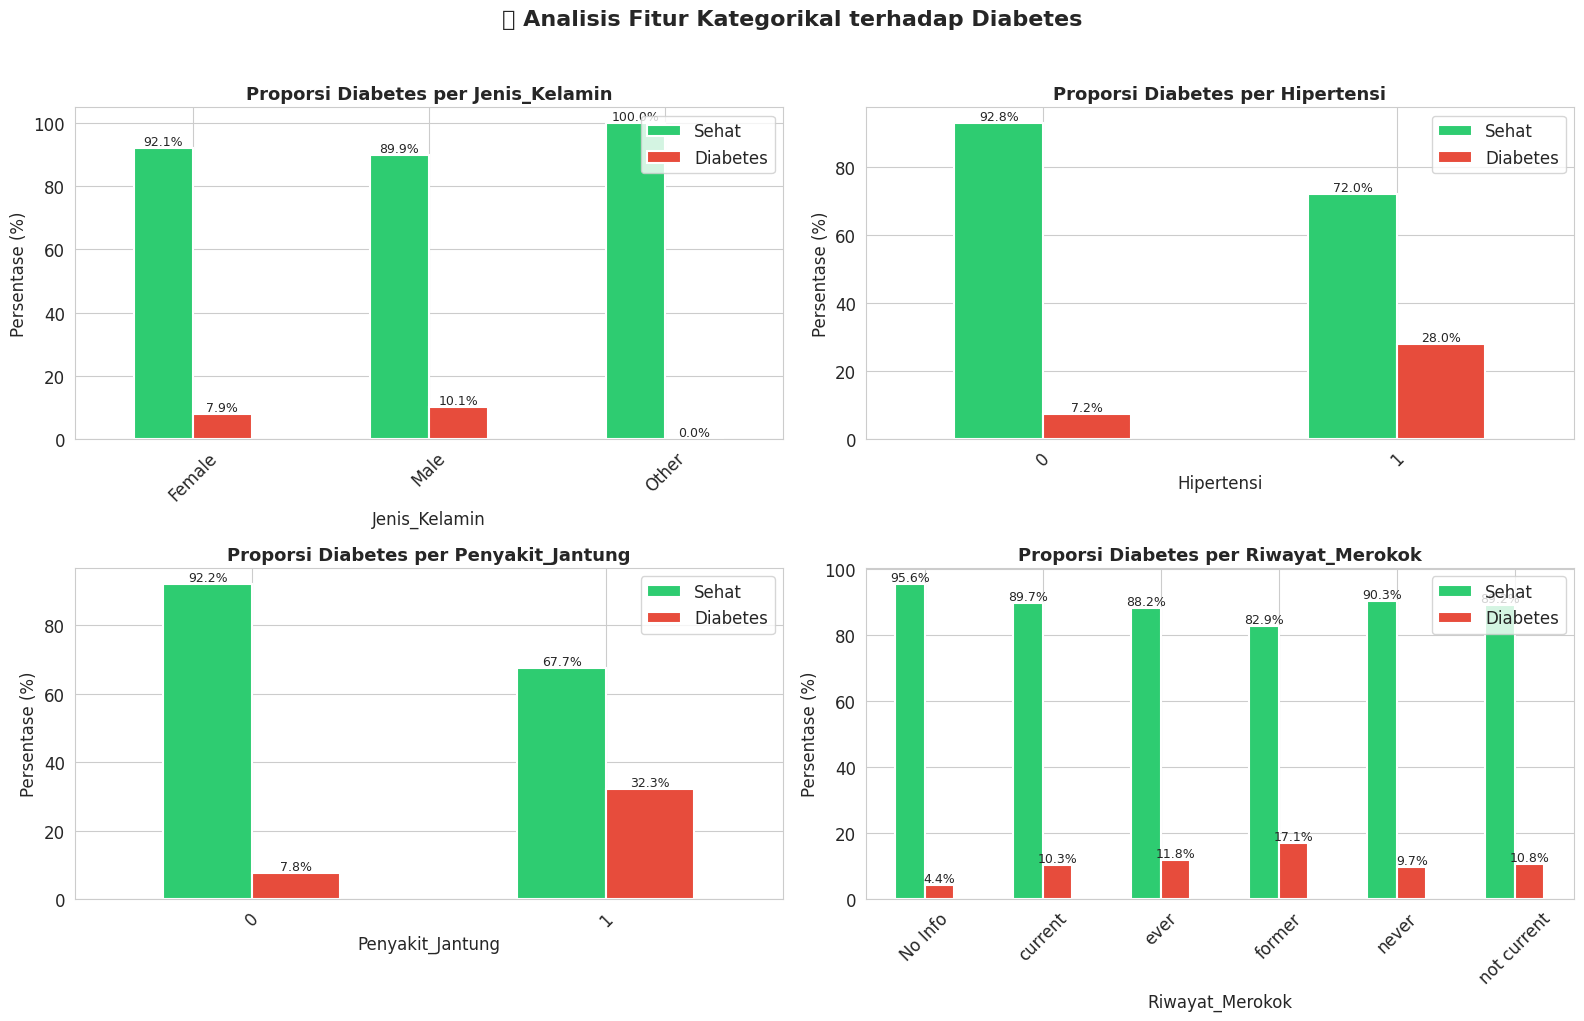

In [7]:
# ============================================================
# CELL 7: EDA — Analisis Fitur Kategorikal
# ============================================================
categorical_features = ['Jenis_Kelamin', 'Hipertensi', 'Penyakit_Jantung', 'Riwayat_Merokok']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, feat in enumerate(categorical_features):
    # Hitung proporsi diabetes per kategori
    ct = pd.crosstab(df[feat], df['Diabetes'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=1.5)

    axes[idx].set_title(f'Proporsi Diabetes per {feat}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel('Persentase (%)')
    axes[idx].legend(['Sehat', 'Diabetes'], loc='upper right')
    axes[idx].tick_params(axis='x', rotation=45)

    # Tambahkan label persentase
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt='%.1f%%', fontsize=9)

plt.suptitle('📊 Analisis Fitur Kategorikal terhadap Diabetes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fitur_kategorikal.png', dpi=150, bbox_inches='tight')
plt.show()

---
# ⚙️ TAHAP 2: PROSES — Preprocessing, SMOTE & Pemodelan


In [8]:
# ============================================================
# CELL 8: Langkah 2.1 — Pembersihan Data (Data Cleaning)
# ============================================================
print("=" * 70)
print("🧹 LANGKAH 2.1: PEMBERSIHAN DATA (DATA CLEANING)")
print("=" * 70)

# Fitur klinis yang TIDAK MUNGKIN bernilai 0
clinical_zero_invalid = ['Kadar_Glukosa', 'BMI']

for col in clinical_zero_invalid:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"\n   ⚠️ {col}: {zero_count} nilai 0 ditemukan → diganti NaN → imputasi Median")
        df[col] = df[col].replace(0, np.nan)
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"      ✅ Imputasi dengan Median = {median_val:.2f}")
    else:
        print(f"\n   ✅ {col}: Tidak ada nilai 0 yang invalid")

# Hapus kategori 'Other' pada Jenis Kelamin (sangat sedikit, bisa bias)
other_count = (df['Jenis_Kelamin'] == 'Other').sum()
if other_count > 0:
    print(f"\n   ⚠️ Jenis Kelamin 'Other': {other_count} data → dihapus (terlalu sedikit)")
    df = df[df['Jenis_Kelamin'] != 'Other'].reset_index(drop=True)

print(f"\n   📊 Dataset setelah cleaning: {df.shape[0]:,} baris, {df.shape[1]} kolom")

🧹 LANGKAH 2.1: PEMBERSIHAN DATA (DATA CLEANING)

   ✅ Kadar_Glukosa: Tidak ada nilai 0 yang invalid

   ✅ BMI: Tidak ada nilai 0 yang invalid

   ⚠️ Jenis Kelamin 'Other': 18 data → dihapus (terlalu sedikit)

   📊 Dataset setelah cleaning: 96,128 baris, 9 kolom


In [9]:
# ============================================================
# CELL 9: Langkah 2.2 — Encoding & Normalisasi
# ============================================================
print("=" * 70)
print("🔄 LANGKAH 2.2: ENCODING & NORMALISASI")
print("=" * 70)

# --- ENCODING ---
# 1. Label Encoding untuk Jenis Kelamin (Biner: Male/Female)
le_gender = LabelEncoder()
df['Jenis_Kelamin'] = le_gender.fit_transform(df['Jenis_Kelamin'])
print(f"\n   ✅ Jenis Kelamin → Label Encoding: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

# 2. One-Hot Encoding untuk Riwayat Merokok (Multi-kategori)
print(f"\n   📋 Kategori Riwayat Merokok sebelum encoding: {df['Riwayat_Merokok'].unique()}")
df = pd.get_dummies(df, columns=['Riwayat_Merokok'], prefix='Merokok', drop_first=False)

# Konversi dummy columns ke int
merokok_cols = [col for col in df.columns if col.startswith('Merokok_')]
df[merokok_cols] = df[merokok_cols].astype(int)
print(f"   ✅ Riwayat Merokok → One-Hot Encoding: {merokok_cols}")

# --- PISAHKAN FITUR (X) DAN TARGET (Y) ---
target_col = 'Diabetes'
X = df.drop(columns=[target_col])
y = df[target_col]

feature_names = X.columns.tolist()
print(f"\n   📋 Fitur yang digunakan ({len(feature_names)}):")
for i, feat in enumerate(feature_names, 1):
    print(f"      {i:2d}. {feat}")
print(f"\n   🎯 Target: {target_col} (0=Sehat, 1=Diabetes)")

🔄 LANGKAH 2.2: ENCODING & NORMALISASI

   ✅ Jenis Kelamin → Label Encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

   📋 Kategori Riwayat Merokok sebelum encoding: ['never' 'No Info' 'current' 'former' 'ever' 'not current']
   ✅ Riwayat Merokok → One-Hot Encoding: ['Merokok_No Info', 'Merokok_current', 'Merokok_ever', 'Merokok_former', 'Merokok_never', 'Merokok_not current']

   📋 Fitur yang digunakan (13):
       1. Jenis_Kelamin
       2. Usia
       3. Hipertensi
       4. Penyakit_Jantung
       5. BMI
       6. HbA1c
       7. Kadar_Glukosa
       8. Merokok_No Info
       9. Merokok_current
      10. Merokok_ever
      11. Merokok_former
      12. Merokok_never
      13. Merokok_not current

   🎯 Target: Diabetes (0=Sehat, 1=Diabetes)


✂️ LANGKAH 2.3: PEMISAHAN DATA & SMOTE

   📊 Pembagian Data (Stratified):
      Training : 76,902 data (80%)
      Testing  : 19,226 data (20%)

   📊 Distribusi Kelas SEBELUM SMOTE (Data Latih):
      Sehat (0)   : 70,116 (91.2%)
      Diabetes (1): 6,786 (8.8%)

   ✅ StandardScaler diterapkan (fit pada training, transform pada testing)

   📊 Distribusi Kelas SETELAH SMOTE (Data Latih):
      Sehat (0)   : 70,116 (50.0%)
      Diabetes (1): 70,116 (50.0%)

   ✅ SMOTE berhasil! Kelas sekarang SEIMBANG (50:50)
   ⚠️ SMOTE diterapkan HANYA pada data latih — data uji TIDAK disentuh!


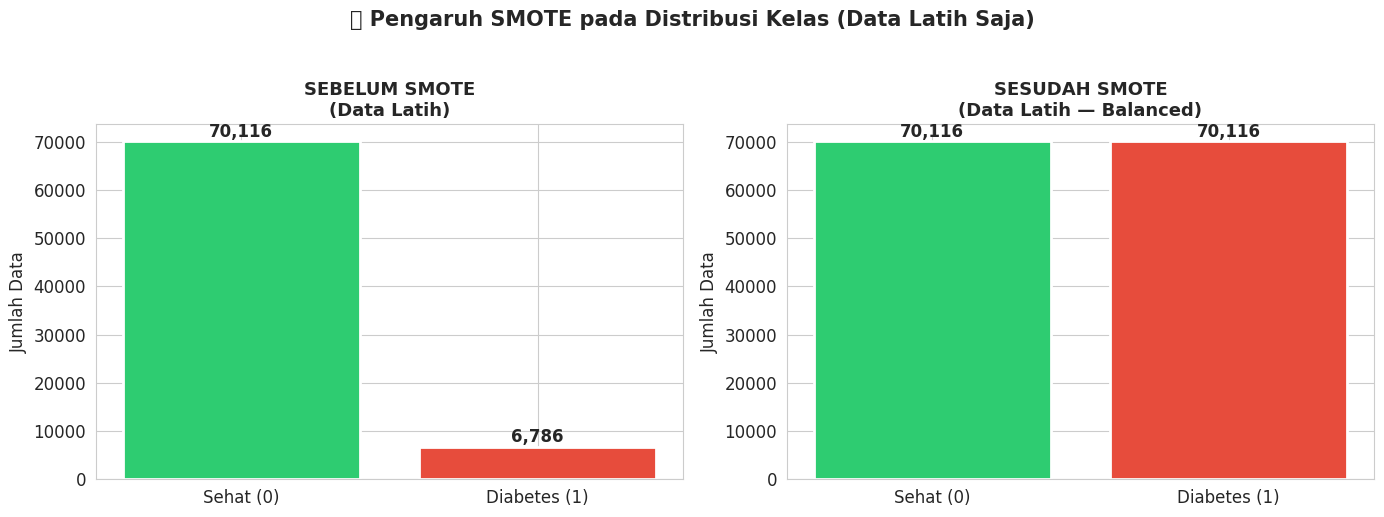

In [10]:
# ============================================================
# CELL 10: Langkah 2.3 — Train-Test Split + SMOTE
# ============================================================
print("=" * 70)
print("✂️ LANGKAH 2.3: PEMISAHAN DATA & SMOTE")
print("=" * 70)

# --- STRATIFIED TRAIN-TEST SPLIT (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Stratified sampling
)

print(f"\n   📊 Pembagian Data (Stratified):")
print(f"      Training : {X_train.shape[0]:,} data ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"      Testing  : {X_test.shape[0]:,} data ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"\n   📊 Distribusi Kelas SEBELUM SMOTE (Data Latih):")
train_counts_before = y_train.value_counts()
print(f"      Sehat (0)   : {train_counts_before[0]:,} ({train_counts_before[0]/len(y_train)*100:.1f}%)")
print(f"      Diabetes (1): {train_counts_before[1]:,} ({train_counts_before[1]/len(y_train)*100:.1f}%)")

# --- NORMALISASI (StandardScaler) ---
# Fit HANYA pada data latih, transform pada kedua set
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names,
    index=X_test.index
)
print(f"\n   ✅ StandardScaler diterapkan (fit pada training, transform pada testing)")

# --- SMOTE: HANYA pada DATA LATIH ---
smote = SMOTE(random_state=42, sampling_strategy='auto')
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\n   📊 Distribusi Kelas SETELAH SMOTE (Data Latih):")
train_counts_after = pd.Series(y_train_resampled).value_counts()
print(f"      Sehat (0)   : {train_counts_after[0]:,} ({train_counts_after[0]/len(y_train_resampled)*100:.1f}%)")
print(f"      Diabetes (1): {train_counts_after[1]:,} ({train_counts_after[1]/len(y_train_resampled)*100:.1f}%)")
print(f"\n   ✅ SMOTE berhasil! Kelas sekarang SEIMBANG (50:50)")
print(f"   ⚠️ SMOTE diterapkan HANYA pada data latih — data uji TIDAK disentuh!")

# Visualisasi sebelum dan sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']
labels_cls = ['Sehat (0)', 'Diabetes (1)']

# Sebelum SMOTE
bars1 = axes[0].bar(labels_cls, train_counts_before.values, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('SEBELUM SMOTE\n(Data Latih)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Data')
for bar, count in zip(bars1, train_counts_before.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Sesudah SMOTE
bars2 = axes[1].bar(labels_cls, train_counts_after.values, color=colors, edgecolor='white', linewidth=2)
axes[1].set_title('SESUDAH SMOTE\n(Data Latih — Balanced)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Data')
for bar, count in zip(bars2, train_counts_after.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('🔄 Pengaruh SMOTE pada Distribusi Kelas (Data Latih Saja)',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ============================================================
# CELL 11: Langkah 2.4 — Random Forest + Hyperparameter Tuning
# ============================================================
print("=" * 70)
print("🌲 LANGKAH 2.4: RANDOM FOREST + HYPERPARAMETER TUNING")
print("=" * 70)

# Definisikan ruang pencarian hyperparameter
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None]
}

print("\n   📋 Parameter Grid yang Diuji:")
for param, values in param_dist.items():
    print(f"      • {param}: {values}")

# Base model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# RandomizedSearchCV dengan 5-Fold Stratified Cross Validation
# Menggunakan RandomizedSearchCV karena dataset besar (100K+)
# Prioritaskan RECALL karena konteks medis
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=50,              # 50 kombinasi acak
    cv=cv_strategy,         # 5-Fold Stratified CV
    scoring='recall',       # RECALL sebagai prioritas utama (konteks medis)
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print(f"\n   🚀 Memulai RandomizedSearchCV (50 iterasi × 5 fold = 250 fit)...")
print(f"   ⏳ Mohon tunggu, proses ini membutuhkan beberapa menit...\n")

random_search.fit(X_train_resampled, y_train_resampled)

print(f"\n   ✅ Pencarian selesai!")
print(f"\n   🏆 Parameter Terbaik:")
for param, value in random_search.best_params_.items():
    print(f"      • {param}: {value}")
print(f"\n   📊 Skor Recall CV Terbaik: {random_search.best_score_:.4f}")

# Ambil model terbaik
best_rf = random_search.best_estimator_

🌲 LANGKAH 2.4: RANDOM FOREST + HYPERPARAMETER TUNING

   📋 Parameter Grid yang Diuji:
      • n_estimators: [100, 200, 300, 500]
      • max_depth: [10, 20, 30, None]
      • min_samples_split: [2, 5, 10]
      • min_samples_leaf: [1, 2, 4]
      • criterion: ['gini', 'entropy']
      • max_features: ['sqrt', 'log2']
      • class_weight: ['balanced', None]

   🚀 Memulai RandomizedSearchCV (50 iterasi × 5 fold = 250 fit)...
   ⏳ Mohon tunggu, proses ini membutuhkan beberapa menit...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

   ✅ Pencarian selesai!

   🏆 Parameter Terbaik:
      • n_estimators: 100
      • min_samples_split: 2
      • min_samples_leaf: 1
      • max_features: sqrt
      • max_depth: 30
      • criterion: entropy
      • class_weight: balanced

   📊 Skor Recall CV Terbaik: 0.9791


In [12]:
# ============================================================
# CELL 12: Hasil Cross-Validation Detail
# ============================================================
print("=" * 70)
print("📊 HASIL CROSS-VALIDATION (5-FOLD)")
print("=" * 70)

cv_results = pd.DataFrame(random_search.cv_results_)
top_5 = cv_results.nsmallest(5, 'rank_test_score')[
    ['rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score', 'params']
].reset_index(drop=True)

print("\n   🏅 Top 5 Kombinasi Parameter:")
for _, row in top_5.iterrows():
    print(f"\n   Rank #{int(row['rank_test_score'])}:")
    print(f"      Recall (CV)  : {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")
    print(f"      Recall (Train): {row['mean_train_score']:.4f}")
    print(f"      Params: {row['params']}")

📊 HASIL CROSS-VALIDATION (5-FOLD)

   🏅 Top 5 Kombinasi Parameter:

   Rank #1:
      Recall (CV)  : 0.9791 ± 0.0009
      Recall (Train): 0.9995
      Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'criterion': 'entropy', 'class_weight': 'balanced'}

   Rank #2:
      Recall (CV)  : 0.9782 ± 0.0010
      Recall (Train): 0.9995
      Params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini', 'class_weight': 'balanced'}

   Rank #3:
      Recall (CV)  : 0.9774 ± 0.0009
      Recall (Train): 0.9969
      Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy', 'class_weight': None}

   Rank #4:
      Recall (CV)  : 0.9765 ± 0.0011
      Recall (Train): 0.9965
      Params: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_featur

---
# 📊 TAHAP 3: OUTPUT — Evaluasi, Threshold Tuning, XAI & Sistem Prediksi


In [13]:
# ============================================================
# CELL 13: Langkah 3.1 — Evaluasi pada Data Uji (Threshold Default = 0.5)
# ============================================================
print("=" * 70)
print("🎯 LANGKAH 3.1: EVALUASI MODEL PADA DATA UJI (20%)")
print("=" * 70)

# Prediksi pada data uji (yang TIDAK pernah dilihat model)
y_pred_default = best_rf.predict(X_test_scaled)
y_pred_proba = best_rf.predict_proba(X_test_scaled)[:, 1]

# === CONFUSION MATRIX (Threshold Default 0.5) ===
cm_default = confusion_matrix(y_test, y_pred_default)
tn_d, fp_d, fn_d, tp_d = cm_default.ravel()

print(f"\n   📊 Confusion Matrix Medis (Threshold = 0.50):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │              Prediksi Sehat  Pred Diab   │")
print(f"   │ Aktual Sehat     TN={tn_d:>5}    FP={fp_d:>5}   │")
print(f"   │ Aktual Diabetes  FN={fn_d:>5}    TP={tp_d:>5}   │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n   📋 Interpretasi Medis:")
print(f"      ✅ True Positive  (TP): {tp_d:,} → Pasien diabetes terdeteksi BENAR")
print(f"      ✅ True Negative  (TN): {tn_d:,} → Pasien sehat terdeteksi BENAR")
print(f"      ⚠️ False Positive (FP): {fp_d:,} → Pasien sehat salah diagnosa diabetes")
print(f"      🚨 False Negative (FN): {fn_d:,} → Pasien diabetes LOLOS deteksi! (BAHAYA)")

# === METRIK EVALUASI (Default) ===
acc_d   = accuracy_score(y_test, y_pred_default)
prec_d  = precision_score(y_test, y_pred_default)
rec_d   = recall_score(y_test, y_pred_default)
f1_d    = f1_score(y_test, y_pred_default)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n   📊 Metrik Evaluasi (Threshold Default = 0.50):")
print(f"   ┌──────────────────────────────────────────┐")
print(f"   │ Accuracy  : {acc_d:.4f}  ({acc_d*100:.2f}%)          │")
print(f"   │ Precision : {prec_d:.4f}  ({prec_d*100:.2f}%)          │")
print(f"   │ ★ RECALL  : {rec_d:.4f}  ({rec_d*100:.2f}%)  ← PRIORITAS │")
print(f"   │ F1-Score  : {f1_d:.4f}  ({f1_d*100:.2f}%)          │")
print(f"   │ ROC-AUC   : {roc_auc:.4f}  ({roc_auc*100:.2f}%)          │")
print(f"   └──────────────────────────────────────────┘")

if rec_d >= 0.95:
    print(f"\n   🎉 RECALL ≥ 95%! Sistem berhasil menekan False Negative seminimal mungkin!")
elif rec_d >= 0.85:
    print(f"\n   ✅ RECALL ≥ 85%. Performa cukup baik untuk screening awal.")
else:
    print(f"\n   ⚠️ RECALL < 85%. Akan dilakukan Threshold Tuning di langkah berikutnya.")

# Classification Report lengkap
print(f"\n   📋 Classification Report Lengkap (Threshold = 0.50):")
target_names = ['Sehat (0)', 'Diabetes (1)']
print(classification_report(y_test, y_pred_default, target_names=target_names))

🎯 LANGKAH 3.1: EVALUASI MODEL PADA DATA UJI (20%)

   📊 Confusion Matrix Medis (Threshold = 0.50):
   ┌─────────────────────────────────────────┐
   │              Prediksi Sehat  Pred Diab   │
   │ Aktual Sehat     TN=17090    FP=  440   │
   │ Aktual Diabetes  FN=  416    TP= 1280   │
   └─────────────────────────────────────────┘

   📋 Interpretasi Medis:
      ✅ True Positive  (TP): 1,280 → Pasien diabetes terdeteksi BENAR
      ✅ True Negative  (TN): 17,090 → Pasien sehat terdeteksi BENAR
      ⚠️ False Positive (FP): 440 → Pasien sehat salah diagnosa diabetes
      🚨 False Negative (FN): 416 → Pasien diabetes LOLOS deteksi! (BAHAYA)

   📊 Metrik Evaluasi (Threshold Default = 0.50):
   ┌──────────────────────────────────────────┐
   │ Accuracy  : 0.9555  (95.55%)          │
   │ Precision : 0.7442  (74.42%)          │
   │ ★ RECALL  : 0.7547  (75.47%)  ← PRIORITAS │
   │ F1-Score  : 0.7494  (74.94%)          │
   │ ROC-AUC   : 0.9653  (96.53%)          │
   └──────────────────────

In [14]:
# ============================================================
# CELL 14: Langkah 3.2 — THRESHOLD TUNING (Youden's J Statistic)
# ============================================================
print("=" * 70)
print("🎚️ LANGKAH 3.2: THRESHOLD TUNING — Optimasi Sensitivitas Medis")
print("=" * 70)
print("""
   📌 ALASAN Threshold Tuning:
      Dalam konteks medis, threshold default (0.50) mungkin TIDAK optimal.
      Kita ingin memaksimalkan RECALL (sensitivitas) agar pasien diabetes
      yang sebenarnya sakit tidak lolos deteksi (False Negative minimal).

      Metode: Youden's J Statistic = max(TPR - FPR)
      Ini menemukan titik pada kurva ROC yang memaksimalkan keseimbangan
      antara True Positive Rate dan False Positive Rate.
""")

# Hitung ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

# === YOUDEN'S J STATISTIC ===
j_scores = tpr - fpr
best_j_idx = np.argmax(j_scores)
optimal_threshold = thresholds[best_j_idx]

print(f"   📊 Analisis Threshold:")
print(f"      Threshold Default : 0.50")
print(f"      Threshold Optimal : {optimal_threshold:.4f} (Youden's J)")
print(f"      Youden's J Score  : {j_scores[best_j_idx]:.4f}")
print(f"      TPR (Recall) pada titik optimal : {tpr[best_j_idx]:.4f}")
print(f"      FPR pada titik optimal          : {fpr[best_j_idx]:.4f}")

# === Evaluasi dengan Threshold Optimal ===
y_pred_tuned = (y_pred_proba >= optimal_threshold).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn_t, fp_t, fn_t, tp_t = cm_tuned.ravel()

acc_t   = accuracy_score(y_test, y_pred_tuned)
prec_t  = precision_score(y_test, y_pred_tuned)
rec_t   = recall_score(y_test, y_pred_tuned)
f1_t    = f1_score(y_test, y_pred_tuned)

print(f"\n   📊 Confusion Matrix Medis (Threshold Optimal = {optimal_threshold:.4f}):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │              Prediksi Sehat  Pred Diab   │")
print(f"   │ Aktual Sehat     TN={tn_t:>5}    FP={fp_t:>5}   │")
print(f"   │ Aktual Diabetes  FN={fn_t:>5}    TP={tp_t:>5}   │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n   📊 Perbandingan Metrik — Default vs Optimal Threshold:")
print(f"   ┌─────────────────────────────────────────────────────────┐")
print(f"   │ Metrik      │ Default (0.50)  │ Optimal ({optimal_threshold:.4f}) │ Δ       │")
print(f"   ├─────────────┼─────────────────┼─────────────────┼─────────┤")
print(f"   │ Accuracy    │ {acc_d:.4f}          │ {acc_t:.4f}          │ {acc_t-acc_d:+.4f}  │")
print(f"   │ Precision   │ {prec_d:.4f}          │ {prec_t:.4f}          │ {prec_t-prec_d:+.4f}  │")
print(f"   │ ★ RECALL    │ {rec_d:.4f}          │ {rec_t:.4f}          │ {rec_t-rec_d:+.4f}  │")
print(f"   │ F1-Score    │ {f1_d:.4f}          │ {f1_t:.4f}          │ {f1_t-f1_d:+.4f}  │")
print(f"   │ ROC-AUC     │ {roc_auc:.4f}          │ {roc_auc:.4f}          │  0.0000 │")
print(f"   │ FN (Bahaya) │ {fn_d:>5}            │ {fn_t:>5}            │ {fn_t-fn_d:+5d}   │")
print(f"   └─────────────────────────────────────────────────────────┘")

# Tentukan threshold yang akan digunakan sistem
# Jika optimal threshold menghasilkan Recall lebih tinggi DAN masih Precision wajar, gunakan.
if rec_t > rec_d and prec_t >= 0.30:
    FINAL_THRESHOLD = optimal_threshold
    print(f"\n   ✅ KEPUTUSAN: Menggunakan Threshold OPTIMAL ({optimal_threshold:.4f})")
    print(f"      Recall naik dari {rec_d:.4f} → {rec_t:.4f} (↑{(rec_t-rec_d)*100:.2f}%)")
    print(f"      False Negative turun dari {fn_d} → {fn_t} (↓{fn_d-fn_t} pasien diselamatkan!)")
    # Tetapkan variabel metrik final
    y_pred = y_pred_tuned
    accuracy = acc_t
    precision = prec_t
    recall = rec_t
    f1 = f1_t
    cm = cm_tuned
    tn, fp, fn, tp = tn_t, fp_t, fn_t, tp_t
else:
    FINAL_THRESHOLD = 0.5
    print(f"\n   ℹ️ KEPUTUSAN: Tetap menggunakan Threshold DEFAULT (0.50)")
    print(f"      Threshold optimal tidak memberikan perbaikan signifikan.")
    y_pred = y_pred_default
    accuracy = acc_d
    precision = prec_d
    recall = rec_d
    f1 = f1_d
    cm = cm_default
    tn, fp, fn, tp = tn_d, fp_d, fn_d, tp_d

print(f"\n   🏆 METRIK FINAL YANG DIGUNAKAN (Threshold = {FINAL_THRESHOLD:.4f}):")
print(f"      Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"      Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"      ★ RECALL  : {recall:.4f}  ({recall*100:.2f}%)")
print(f"      F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print(f"      ROC-AUC   : {roc_auc:.4f}  ({roc_auc*100:.2f}%)")

# Classification Report dengan threshold final
print(f"\n   📋 Classification Report (Threshold = {FINAL_THRESHOLD:.4f}):")
print(classification_report(y_test, y_pred, target_names=target_names))

🎚️ LANGKAH 3.2: THRESHOLD TUNING — Optimasi Sensitivitas Medis

   📌 ALASAN Threshold Tuning:
      Dalam konteks medis, threshold default (0.50) mungkin TIDAK optimal.
      Kita ingin memaksimalkan RECALL (sensitivitas) agar pasien diabetes
      yang sebenarnya sakit tidak lolos deteksi (False Negative minimal).

      Metode: Youden's J Statistic = max(TPR - FPR)
      Ini menemukan titik pada kurva ROC yang memaksimalkan keseimbangan
      antara True Positive Rate dan False Positive Rate.

   📊 Analisis Threshold:
      Threshold Default : 0.50
      Threshold Optimal : 0.1579 (Youden's J)
      Youden's J Score  : 0.7827
      TPR (Recall) pada titik optimal : 0.8986
      FPR pada titik optimal          : 0.1159

   📊 Confusion Matrix Medis (Threshold Optimal = 0.1579):
   ┌─────────────────────────────────────────┐
   │              Prediksi Sehat  Pred Diab   │
   │ Aktual Sehat     TN=15499    FP= 2031   │
   │ Aktual Diabetes  FN=  172    TP= 1524   │
   └──────────────────

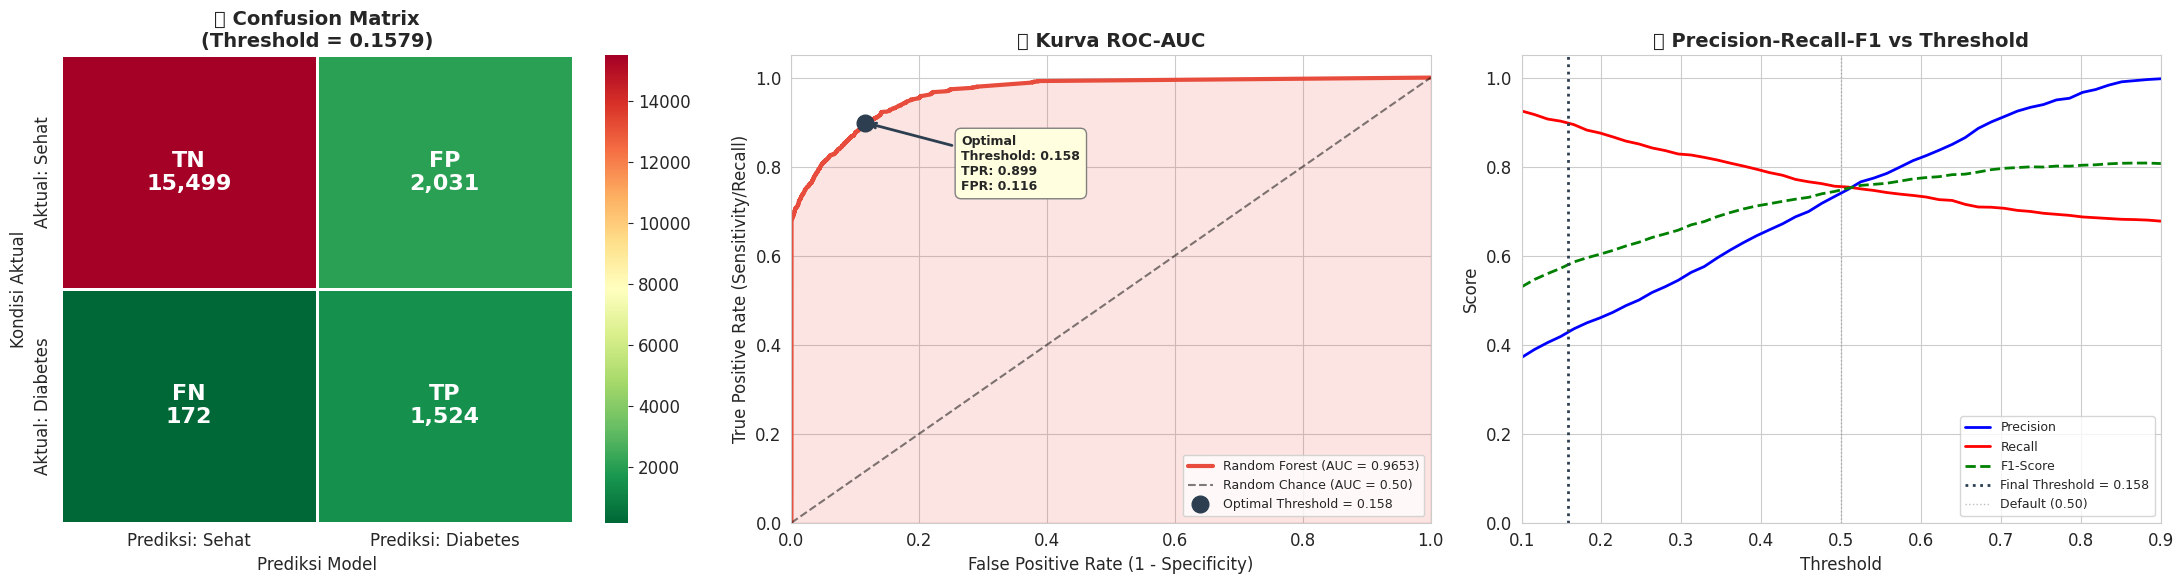

In [15]:
# ============================================================
# CELL 15: Visualisasi Confusion Matrix, ROC Curve & Threshold
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Confusion Matrix Heatmap (Final) ---
cm_labels = np.array([[f'TN\n{tn:,}', f'FP\n{fp:,}'],
                       [f'FN\n{fn:,}', f'TP\n{tp:,}']])

sns.heatmap(cm, annot=cm_labels, fmt='', cmap='RdYlGn_r',
            xticklabels=['Prediksi: Sehat', 'Prediksi: Diabetes'],
            yticklabels=['Aktual: Sehat', 'Aktual: Diabetes'],
            cbar=True, linewidths=2, linecolor='white',
            annot_kws={'size': 16, 'fontweight': 'bold'}, ax=axes[0])
axes[0].set_title(f'🏥 Confusion Matrix\n(Threshold = {FINAL_THRESHOLD:.4f})',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prediksi Model', fontsize=12)
axes[0].set_ylabel('Kondisi Aktual', fontsize=12)

# --- ROC Curve ---
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=3,
             label=f'Random Forest (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Chance (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
axes[1].set_title('📈 Kurva ROC-AUC', fontsize=14, fontweight='bold')

# Tandai titik optimal (Youden's J) dan titik default
axes[1].plot(fpr[best_j_idx], tpr[best_j_idx], 'o', markersize=12, color='#2c3e50',
             label=f"Optimal Threshold = {optimal_threshold:.3f}")
axes[1].annotate(f'Optimal\nThreshold: {optimal_threshold:.3f}\nTPR: {tpr[best_j_idx]:.3f}\nFPR: {fpr[best_j_idx]:.3f}',
                 xy=(fpr[best_j_idx], tpr[best_j_idx]),
                 xytext=(fpr[best_j_idx]+0.15, tpr[best_j_idx]-0.15),
                 fontsize=9, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2),
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='gray'))
axes[1].legend(loc='lower right', fontsize=9)

# --- Threshold vs Metrik ---
# Hitung precision, recall, F1 untuk berbagai threshold
th_range = np.linspace(0.1, 0.9, 50)
th_precisions = []
th_recalls = []
th_f1s = []
for th_val in th_range:
    y_th = (y_pred_proba >= th_val).astype(int)
    if y_th.sum() > 0 and (1 - y_th).sum() > 0:
        th_precisions.append(precision_score(y_test, y_th, zero_division=0))
        th_recalls.append(recall_score(y_test, y_th))
        th_f1s.append(f1_score(y_test, y_th))
    else:
        th_precisions.append(0)
        th_recalls.append(0)
        th_f1s.append(0)

axes[2].plot(th_range, th_precisions, 'b-', linewidth=2, label='Precision')
axes[2].plot(th_range, th_recalls, 'r-', linewidth=2, label='Recall')
axes[2].plot(th_range, th_f1s, 'g--', linewidth=2, label='F1-Score')
axes[2].axvline(x=FINAL_THRESHOLD, color='#2c3e50', linestyle=':', linewidth=2,
                label=f'Final Threshold = {FINAL_THRESHOLD:.3f}')
axes[2].axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5,
                label='Default (0.50)')
axes[2].set_xlabel('Threshold', fontsize=12)
axes[2].set_ylabel('Score', fontsize=12)
axes[2].set_title('🎚️ Precision-Recall-F1 vs Threshold', fontsize=14, fontweight='bold')
axes[2].legend(loc='best', fontsize=9)
axes[2].set_xlim([0.1, 0.9])
axes[2].set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('evaluasi_model.png', dpi=150, bbox_inches='tight')
plt.show()

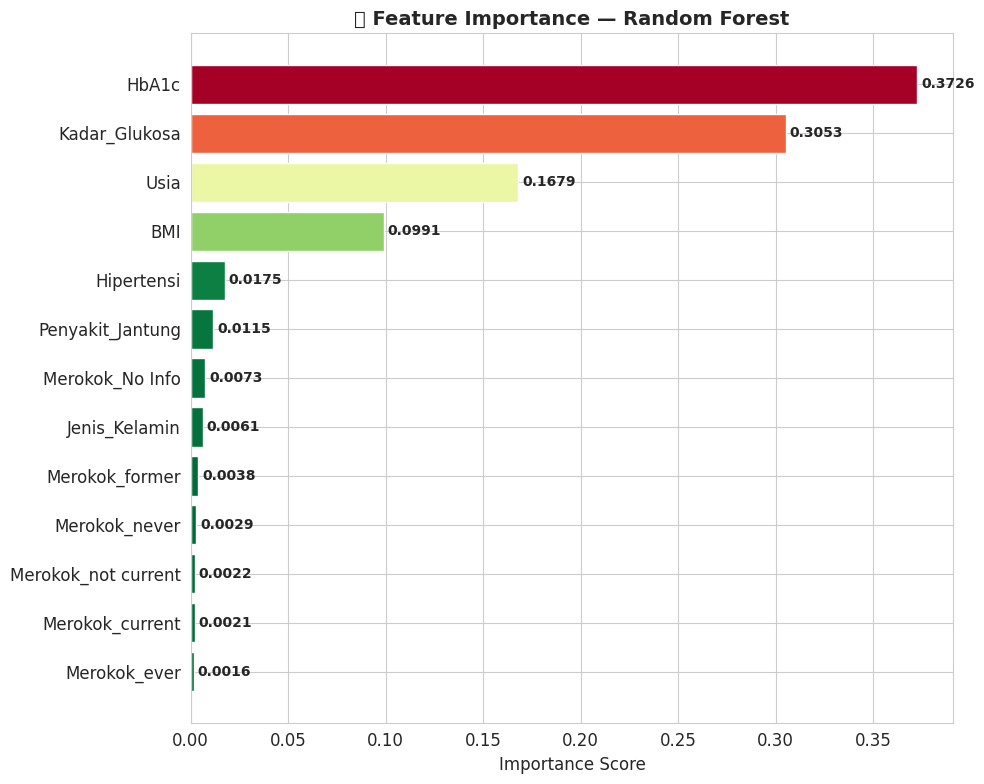

In [16]:
# ============================================================
# CELL 16: Feature Importance dari Random Forest
# ============================================================
importances = best_rf.feature_importances_
feat_importance = pd.DataFrame({
    'Fitur': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(feat_importance['Fitur'], feat_importance['Importance'],
               color=plt.cm.RdYlGn_r(feat_importance['Importance'] / feat_importance['Importance'].max()),
               edgecolor='white', linewidth=1)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('🌲 Feature Importance — Random Forest', fontsize=14, fontweight='bold')

# Label nilai
for bar, imp in zip(bars, feat_importance['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2.,
            f'{imp:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

🔍 LANGKAH 3.3: EXPLAINABLE AI — SHAP (Global Interpretability)

   ⏳ Menghitung SHAP values (TreeExplainer) untuk 1000 sampel...
   ✅ SHAP values berhasil dihitung!
   📋 Shape SHAP values: (1000, 13)
   📋 Base value (kelas Diabetes): 0.5001

   📊 SHAP Summary Plot — Peringkat Fitur Global:


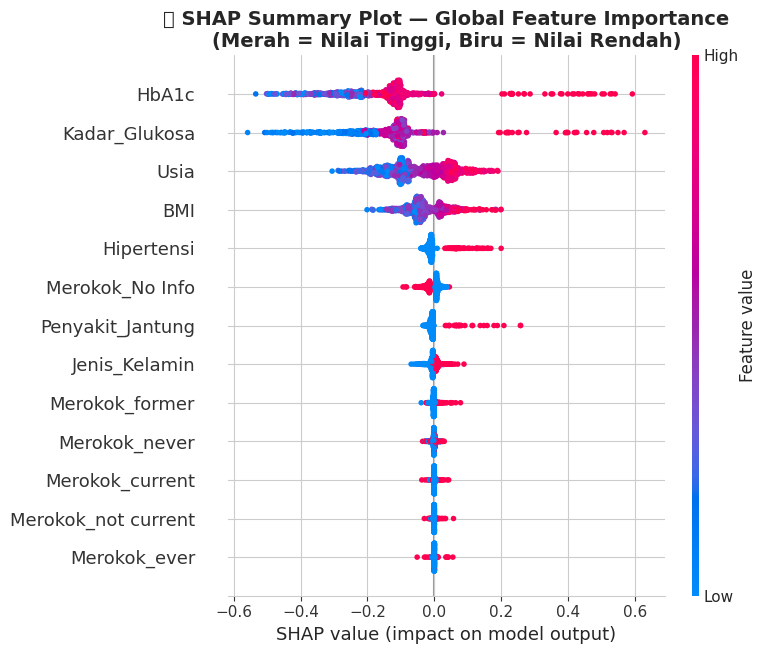

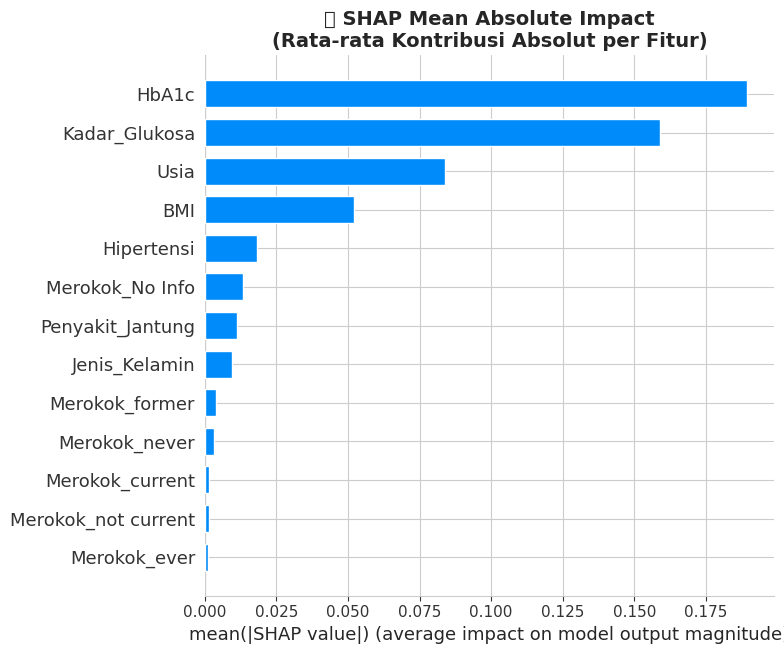


   📋 Interpretasi SHAP Global:
       1. HbA1c                     0.1893  ██████████████████████████████
       2. Kadar_Glukosa             0.1591  █████████████████████████
       3. Usia                      0.0840  █████████████
       4. BMI                       0.0520  ████████
       5. Hipertensi                0.0182  ██
       6. Merokok_No Info           0.0132  ██
       7. Penyakit_Jantung          0.0114  █
       8. Jenis_Kelamin             0.0094  █
       9. Merokok_former            0.0038  
      10. Merokok_never             0.0033  
      11. Merokok_current           0.0016  
      12. Merokok_not current       0.0015  
      13. Merokok_ever              0.0012  


In [17]:
# ============================================================
# CELL 17: Langkah 3.3 — XAI: SHAP Global Interpretability
#           (Summary Plot — Peringkat Fitur Paling Penting)
# ============================================================
print("=" * 70)
print("🔍 LANGKAH 3.3: EXPLAINABLE AI — SHAP (Global Interpretability)")
print("=" * 70)

# --- Helper: Kompatibilitas SHAP untuk berbagai versi ---
def get_shap_values_class1(shap_vals):
    """
    Mengekstrak SHAP values untuk kelas positif (Diabetes).
    Kompatibel dengan SHAP versi lama (list) dan baru (3D array / 2D array).
    """
    if isinstance(shap_vals, list):
        # Versi lama: list of arrays [class_0_shap, class_1_shap]
        return shap_vals[1]
    elif isinstance(shap_vals, np.ndarray):
        if shap_vals.ndim == 3:
            # Versi baru: 3D array (n_samples, n_features, n_classes)
            return shap_vals[:, :, 1]
        else:
            # 2D array: sudah dalam format (n_samples, n_features) untuk kelas positif
            return shap_vals
    else:
        # shap.Explanation object
        return shap_vals.values

def get_shap_base_value(explainer_obj):
    """
    Mengekstrak base value (expected value) untuk kelas positif.
    Kompatibel dengan SHAP versi lama dan baru.
    """
    ev = explainer_obj.expected_value
    if isinstance(ev, (list, np.ndarray)) and len(ev) > 1:
        return ev[1]  # Kelas positif
    elif isinstance(ev, (list, np.ndarray)):
        return ev[0]
    else:
        return float(ev)

# Gunakan subsample untuk efisiensi (SHAP bisa lambat pada data besar)
# Ambil 1000 sampel acak dari data uji
sample_size = min(1000, X_test_scaled.shape[0])
np.random.seed(42)
sample_indices = np.random.choice(X_test_scaled.index, size=sample_size, replace=False)
X_test_sample = X_test_scaled.loc[sample_indices]

print(f"\n   ⏳ Menghitung SHAP values (TreeExplainer) untuk {sample_size} sampel...")

# TreeExplainer untuk Random Forest → sangat efisien
explainer_shap = shap.TreeExplainer(best_rf)
shap_values_raw = explainer_shap.shap_values(X_test_sample)

# Ekstrak SHAP values untuk kelas positif (Diabetes)
shap_values_class1 = get_shap_values_class1(shap_values_raw)
shap_base_value = get_shap_base_value(explainer_shap)

print(f"   ✅ SHAP values berhasil dihitung!")
print(f"   📋 Shape SHAP values: {shap_values_class1.shape}")
print(f"   📋 Base value (kelas Diabetes): {shap_base_value:.4f}\n")

# --- SHAP SUMMARY PLOT (Global) ---
print("   📊 SHAP Summary Plot — Peringkat Fitur Global:")
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_class1, X_test_sample,
                  feature_names=feature_names,
                  show=False, max_display=len(feature_names))
plt.title('🔍 SHAP Summary Plot — Global Feature Importance\n'
          '(Merah = Nilai Tinggi, Biru = Nilai Rendah)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP Bar Plot (Mean Absolute) ---
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values_class1, X_test_sample,
                  feature_names=feature_names,
                  plot_type='bar', show=False, max_display=len(feature_names))
plt.title('📊 SHAP Mean Absolute Impact\n(Rata-rata Kontribusi Absolut per Fitur)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n   📋 Interpretasi SHAP Global:")
# Hitung mean absolute SHAP values
mean_shap = np.abs(shap_values_class1).mean(axis=0)
shap_ranking = pd.DataFrame({
    'Fitur': feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False)

for i, (_, row) in enumerate(shap_ranking.iterrows(), 1):
    bar = '█' * int(row['Mean |SHAP|'] / shap_ranking['Mean |SHAP|'].max() * 30)
    print(f"      {i:2d}. {row['Fitur']:<25} {row['Mean |SHAP|']:.4f}  {bar}")

🔍 SHAP WATERFALL PLOT — Interpretasi Individual Pasien

   🏥 Analisis Pasien Contoh (Index: 87333):
      Prediksi (Threshold=0.158): DIABETES
      Probabilitas Diabetes: 100.0%
      Status Aktual: Diabetes

   📋 Data Klinis Pasien:
      • Jenis_Kelamin: 1.0
      • Usia: 62.0
      • Hipertensi: 0.0
      • Penyakit_Jantung: 1.0
      • BMI: 27.32
      • HbA1c: 9.0
      • Kadar_Glukosa: 126.0
      • Merokok_No Info: 0.0
      • Merokok_current: 0.0
      • Merokok_ever: 0.0
      • Merokok_former: 0.0
      • Merokok_never: 1.0
      • Merokok_not current: 0.0


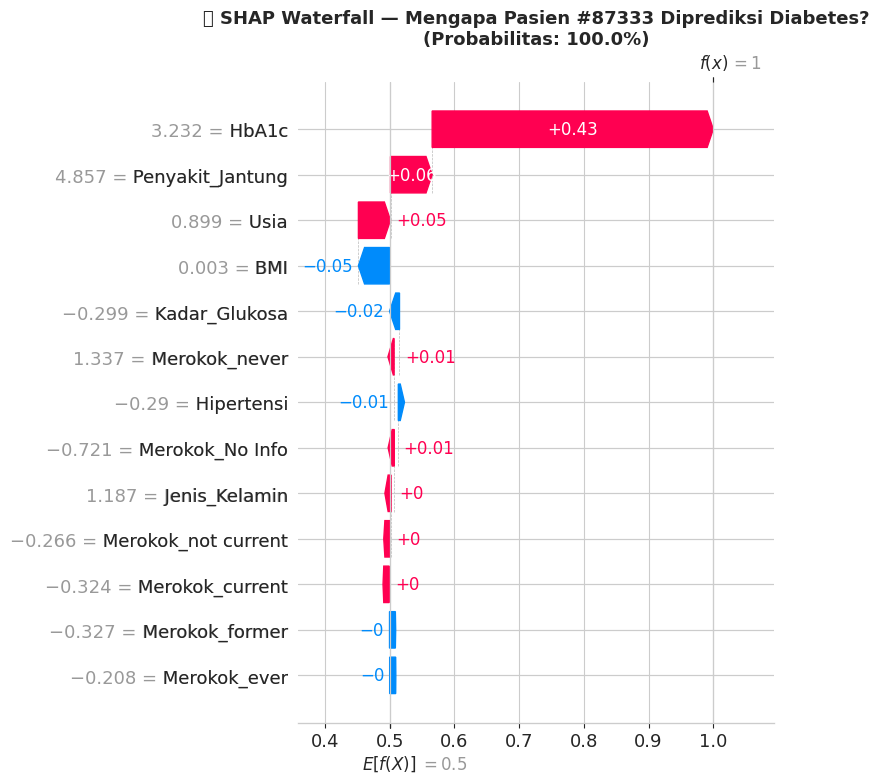


   📝 Narasi Interpretasi XAI:
      "Pasien #87333 diprediksi DIABETES karena:
       🔴 HbA1c = 9.00 → meningkatkan risiko (+0.4343)
       🔴 Penyakit_Jantung = 1.00 → meningkatkan risiko (+0.0643)
       🔴 Usia = 62.00 → meningkatkan risiko (+0.0496)
       🟢 BMI = 27.32 → menurunkan risiko (-0.0481)
       🟢 Kadar_Glukosa = 126.00 → menurunkan risiko (-0.0153)
      "


In [18]:
# ============================================================
# CELL 18: XAI — SHAP Waterfall Plot (Local Interpretability)
# ============================================================
print("=" * 70)
print("🔍 SHAP WATERFALL PLOT — Interpretasi Individual Pasien")
print("=" * 70)

# Cari satu pasien yang diprediksi positif diabetes dengan confidence tinggi
proba_sample = best_rf.predict_proba(X_test_sample)[:, 1]
# Pilih pasien dengan probabilitas diabetes tertinggi
high_risk_idx = np.argmax(proba_sample)
patient_idx_global = X_test_sample.index[high_risk_idx]

# Prediksi dengan threshold final
patient_pred = 1 if proba_sample[high_risk_idx] >= FINAL_THRESHOLD else 0

print(f"\n   🏥 Analisis Pasien Contoh (Index: {patient_idx_global}):")
print(f"      Prediksi (Threshold={FINAL_THRESHOLD:.3f}): {'DIABETES' if patient_pred == 1 else 'SEHAT'}")
print(f"      Probabilitas Diabetes: {proba_sample[high_risk_idx]*100:.1f}%")
print(f"      Status Aktual: {'Diabetes' if y_test.loc[patient_idx_global] == 1 else 'Sehat'}")

# Data pasien (dalam skala asli untuk interpretasi)
patient_original = X_test.loc[patient_idx_global]
print(f"\n   📋 Data Klinis Pasien:")
for feat in feature_names:
    val = patient_original[feat]
    print(f"      • {feat}: {val}")

# SHAP Waterfall Plot
fig, ax = plt.subplots(figsize=(12, 8))
shap_explanation = shap.Explanation(
    values=shap_values_class1[high_risk_idx],
    base_values=shap_base_value,
    data=X_test_sample.iloc[high_risk_idx].values,
    feature_names=feature_names
)
shap.waterfall_plot(shap_explanation, show=False, max_display=len(feature_names))
plt.title(f'🔍 SHAP Waterfall — Mengapa Pasien #{patient_idx_global} Diprediksi Diabetes?\n'
          f'(Probabilitas: {proba_sample[high_risk_idx]*100:.1f}%)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# Interpretasi tekstual
print(f"\n   📝 Narasi Interpretasi XAI:")
shap_patient = pd.DataFrame({
    'Fitur': feature_names,
    'SHAP_Value': shap_values_class1[high_risk_idx],
    'Nilai_Asli': patient_original.values
}).sort_values('SHAP_Value', key=abs, ascending=False)

print(f'      "Pasien #{patient_idx_global} diprediksi DIABETES karena:')
for _, row in shap_patient.head(5).iterrows():
    direction = "meningkatkan" if row['SHAP_Value'] > 0 else "menurunkan"
    emoji = "🔴" if row['SHAP_Value'] > 0 else "🟢"
    print(f"       {emoji} {row['Fitur']} = {row['Nilai_Asli']:.2f} → {direction} risiko ({row['SHAP_Value']:+.4f})")
print(f'      "')

🍋 LIME — Local Interpretability untuk Pasien Individual

   🏥 LIME Explanation untuk Pasien #87333:
      Prediksi Model: Diabetes

   📋 Kontribusi Fitur (LIME):


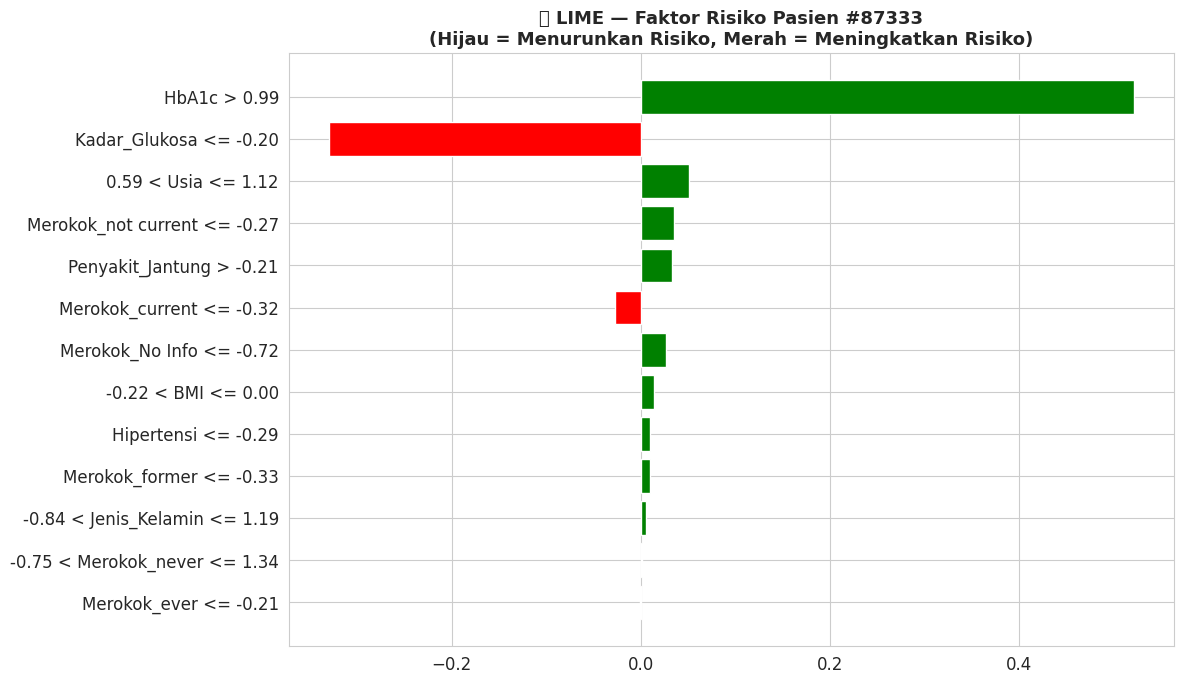

      🔴 HbA1c > 0.99: +0.5213
      🟢 Kadar_Glukosa <= -0.20: -0.3301
      🔴 0.59 < Usia <= 1.12: +0.0506
      🔴 Merokok_not current <= -0.27: +0.0350
      🔴 Penyakit_Jantung > -0.21: +0.0329
      🟢 Merokok_current <= -0.32: -0.0277
      🔴 Merokok_No Info <= -0.72: +0.0270
      🔴 -0.22 < BMI <= 0.00: +0.0135
      🔴 Hipertensi <= -0.29: +0.0097
      🔴 Merokok_former <= -0.33: +0.0097
      🔴 -0.84 < Jenis_Kelamin <= 1.19: +0.0050
      🔴 -0.75 < Merokok_never <= 1.34: +0.0012
      🟢 Merokok_ever <= -0.21: -0.0006


In [19]:
# ============================================================
# CELL 19: XAI — LIME (Local Interpretable Model-Agnostic Explanations)
# ============================================================
print("=" * 70)
print("🍋 LIME — Local Interpretability untuk Pasien Individual")
print("=" * 70)

# Inisialisasi LIME Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_resampled.values if isinstance(X_train_resampled, pd.DataFrame)
                  else X_train_resampled,
    feature_names=feature_names,
    class_names=['Sehat', 'Diabetes'],
    mode='classification',
    random_state=42
)

# Jelaskan pasien yang sama dengan SHAP
patient_data = X_test_scaled.loc[patient_idx_global].values

lime_exp = lime_explainer.explain_instance(
    patient_data,
    best_rf.predict_proba,
    num_features=len(feature_names),
    top_labels=1
)

print(f"\n   🏥 LIME Explanation untuk Pasien #{patient_idx_global}:")
print(f"      Prediksi Model: {'Diabetes' if best_rf.predict(patient_data.reshape(1, -1))[0] == 1 else 'Sehat'}")
print(f"\n   📋 Kontribusi Fitur (LIME):")

# Tampilkan sebagai bar chart
fig = lime_exp.as_pyplot_figure(label=1)
fig.set_size_inches(12, 7)
plt.title(f'🍋 LIME — Faktor Risiko Pasien #{patient_idx_global}\n'
          f'(Hijau = Menurunkan Risiko, Merah = Meningkatkan Risiko)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

# Detail LIME
lime_list = lime_exp.as_list(label=1)
for feat_rule, weight in sorted(lime_list, key=lambda x: abs(x[1]), reverse=True):
    emoji = "🔴" if weight > 0 else "🟢"
    print(f"      {emoji} {feat_rule}: {weight:+.4f}")

In [20]:
# ============================================================
# CELL 20: Langkah 3.4 — SISTEM PREDIKSI AKHIR (End-Deliverables)
# ============================================================
print("=" * 70)
print("🏥 LANGKAH 3.4: SISTEM PREDIKSI DIABETES — OUTPUT AKHIR")
print("=" * 70)

def prediksi_diabetes(data_pasien, model, scaler_obj, feature_names_list,
                      shap_explainer, X_train_data, threshold=None, show_plot=True):
    """
    Sistem Prediksi Diabetes Lengkap dengan 4 Output Deliverables:
    1. Status Prediksi Biner (menggunakan Threshold Optimal)
    2. Skor Probabilitas (Confidence Score)
    3. Visualisasi Faktor Risiko (SHAP)
    4. Rekomendasi Medis Dasar

    Parameters:
    -----------
    data_pasien : list
        List nilai fitur sesuai urutan feature_names_list
    model : RandomForestClassifier
        Model yang sudah dilatih
    scaler_obj : StandardScaler
        Scaler yang sudah di-fit
    feature_names_list : list
        Nama-nama fitur
    shap_explainer : shap.TreeExplainer
        SHAP explainer object
    X_train_data : array-like
        Data training untuk LIME
    threshold : float or None
        Threshold keputusan. Jika None, gunakan default 0.5.
    show_plot : bool
        Tampilkan plot atau tidak
    """

    if threshold is None:
        threshold = 0.5

    print("\n" + "═" * 70)
    print("  🏥  LAPORAN PREDIKSI DIABETES — SISTEM AI DIAGNOSTIC")
    print("═" * 70)

    # --- Persiapan Data ---
    df_input = pd.DataFrame([data_pasien], columns=feature_names_list)
    df_scaled = pd.DataFrame(
        scaler_obj.transform(df_input),
        columns=feature_names_list
    )

    # --- OUTPUT 1: Status Prediksi Biner (MENGGUNAKAN THRESHOLD OPTIMAL) ---
    probabilitas = model.predict_proba(df_scaled)[0]
    prob_sehat = probabilitas[0] * 100
    prob_diabetes = probabilitas[1] * 100

    # Keputusan berdasarkan threshold optimal
    prediksi = 1 if probabilitas[1] >= threshold else 0
    status = "⚠️ BERISIKO DIABETES" if prediksi == 1 else "✅ SEHAT (Tidak Berisiko Diabetes)"

    print(f"\n  ╔══════════════════════════════════════════════════════╗")
    print(f"  ║  OUTPUT 1: STATUS PREDIKSI (Threshold = {threshold:.4f})    ║")
    print(f"  ║  {status:<52}║")
    print(f"  ╚══════════════════════════════════════════════════════╝")

    # --- OUTPUT 2: Skor Probabilitas ---
    print(f"\n  ╔══════════════════════════════════════════════════════╗")
    print(f"  ║  OUTPUT 2: SKOR PROBABILITAS (CONFIDENCE)           ║")
    print(f"  ║                                                      ║")
    if prediksi == 1:
        print(f"  ║  Model memiliki tingkat keyakinan {prob_diabetes:.1f}%             ║")
        print(f"  ║  bahwa pasien ini berisiko Diabetes Tipe 2.         ║")
    else:
        print(f"  ║  Model memiliki tingkat keyakinan {prob_sehat:.1f}%             ║")
        print(f"  ║  bahwa pasien ini dalam kondisi SEHAT.              ║")
    print(f"  ║                                                      ║")
    print(f"  ║  Probabilitas Sehat   : {prob_sehat:>6.2f}%                    ║")
    print(f"  ║  Probabilitas Diabetes: {prob_diabetes:>6.2f}%                    ║")
    print(f"  ║  Threshold Keputusan  : {threshold*100:>6.2f}%                    ║")
    print(f"  ╚══════════════════════════════════════════════════════╝")

    # --- OUTPUT 3: Visualisasi Faktor Risiko (SHAP) ---
    shap_vals_raw_local = shap_explainer.shap_values(df_scaled)
    shap_vals_c1 = get_shap_values_class1(shap_vals_raw_local)
    shap_bv = get_shap_base_value(shap_explainer)

    if show_plot:
        # SHAP Waterfall untuk pasien ini
        shap_exp = shap.Explanation(
            values=shap_vals_c1[0],
            base_values=shap_bv,
            data=df_scaled.values[0],
            feature_names=feature_names_list
        )

        fig, axes = plt.subplots(1, 2, figsize=(18, 7))

        # SHAP Force Plot sebagai bar chart manual
        shap_df = pd.DataFrame({
            'Fitur': feature_names_list,
            'SHAP': shap_vals_c1[0],
            'Nilai_Asli': df_input.values[0]
        }).sort_values('SHAP', ascending=True)

        colors_shap = ['#e74c3c' if v > 0 else '#2ecc71' for v in shap_df['SHAP']]
        axes[0].barh(shap_df['Fitur'], shap_df['SHAP'], color=colors_shap,
                     edgecolor='white', linewidth=1.5)
        axes[0].set_xlabel('SHAP Value (Kontribusi terhadap Risiko)', fontsize=11)
        axes[0].set_title('🔍 Faktor Risiko Diabetes\n(Merah = ↑ Risiko, Hijau = ↓ Risiko)',
                          fontsize=13, fontweight='bold')
        axes[0].axvline(x=0, color='black', linewidth=1, linestyle='--')

        # Heatmap status parameter kesehatan
        normal_ranges = {
            'Kadar_Glukosa': (70, 140),
            'HbA1c': (4.0, 5.7),
            'BMI': (18.5, 24.9),
            'Usia': (0, 100),
        }

        risk_data = []
        risk_labels = []
        for feat in feature_names_list:
            val = data_pasien[feature_names_list.index(feat)] if isinstance(data_pasien, list) else df_input[feat].values[0]
            if feat in normal_ranges:
                low, high = normal_ranges[feat]
                if val < low:
                    risk_score = -1
                elif val > high:
                    risk_score = (val - high) / high
                    risk_score = min(risk_score, 2)
                else:
                    risk_score = 0
                risk_data.append(risk_score)
                risk_labels.append(f"{feat}\n({val:.1f})")

        if risk_data:
            risk_array = np.array(risk_data).reshape(1, -1)
            im = axes[1].imshow(risk_array, cmap='RdYlGn_r', aspect='auto', vmin=-1, vmax=2)
            axes[1].set_xticks(range(len(risk_labels)))
            axes[1].set_xticklabels(risk_labels, fontsize=10, rotation=45, ha='right')
            axes[1].set_yticks([])
            axes[1].set_title('🌡️ Status Parameter Kesehatan\n(Hijau = Normal, Merah = Abnormal)',
                              fontsize=13, fontweight='bold')
            plt.colorbar(im, ax=axes[1], label='Risk Score', shrink=0.6)

            for i, score in enumerate(risk_data):
                status_txt = "NORMAL" if score == 0 else ("TINGGI" if score > 0 else "RENDAH")
                color_txt = 'white' if abs(score) > 0.5 else 'black'
                axes[1].text(i, 0, status_txt, ha='center', va='center',
                             fontweight='bold', fontsize=11, color=color_txt)

        plt.suptitle(f'📊 Visualisasi Faktor Risiko Diabetes — Pasien',
                     fontsize=15, fontweight='bold', y=1.03)
        plt.tight_layout()
        plt.savefig('output_faktor_risiko.png', dpi=150, bbox_inches='tight')
        plt.show()

    print(f"\n  ╔══════════════════════════════════════════════════════╗")
    print(f"  ║  OUTPUT 3: FAKTOR RISIKO (SHAP Analysis)           ║")
    print(f"  ╚══════════════════════════════════════════════════════╝")

    shap_report = pd.DataFrame({
        'Fitur': feature_names_list,
        'SHAP': shap_vals_c1[0],
        'Nilai': df_input.values[0]
    }).sort_values('SHAP', key=abs, ascending=False)

    for _, row in shap_report.iterrows():
        emoji = "🔴" if row['SHAP'] > 0 else "🟢"
        direction = "MENINGKATKAN" if row['SHAP'] > 0 else "MENURUNKAN"
        print(f"   {emoji} {row['Fitur']:<25} = {row['Nilai']:<10.2f} → {direction} risiko ({row['SHAP']:+.4f})")

    # --- OUTPUT 4: Rekomendasi Medis Dasar ---
    print(f"\n  ╔══════════════════════════════════════════════════════╗")
    print(f"  ║  OUTPUT 4: REKOMENDASI MEDIS DASAR                  ║")
    print(f"  ╚══════════════════════════════════════════════════════╝")

    rekomendasi = []

    # Ambil top 3 faktor risiko positif
    top_risks = shap_report[shap_report['SHAP'] > 0].head(3)

    for _, row in top_risks.iterrows():
        feat = row['Fitur']
        val = row['Nilai']

        if feat == 'Kadar_Glukosa' or feat == 'HbA1c':
            rekomendasi.append(
                f"   📌 {feat} Anda ({val:.1f}) di atas batas normal.\n"
                f"      → Rekomendasi: Lakukan tes gula darah puasa secara rutin.\n"
                f"      → Kurangi konsumsi karbohidrat sederhana & gula tambahan.\n"
                f"      → Konsultasi dengan dokter endokrin untuk pemantauan berkala."
            )
        elif feat == 'BMI':
            if val > 30:
                rekomendasi.append(
                    f"   📌 BMI Anda ({val:.1f}) termasuk kategori OBESITAS.\n"
                    f"      → Rekomendasi: Program diet terkontrol (defisit kalori 500-700 kcal/hari).\n"
                    f"      → Aktivitas fisik: Jalan cepat 30 menit/hari, 5x/minggu.\n"
                    f"      → Target penurunan berat badan: 5-10% dalam 6 bulan pertama."
                )
            elif val > 25:
                rekomendasi.append(
                    f"   📌 BMI Anda ({val:.1f}) termasuk OVERWEIGHT.\n"
                    f"      → Rekomendasi: Intervensi diet seimbang & pengelolaan berat badan.\n"
                    f"      → Tingkatkan aktivitas fisik minimal 150 menit/minggu."
                )
        elif feat == 'Usia':
            if val >= 45:
                rekomendasi.append(
                    f"   📌 Usia Anda ({val:.0f} tahun) memasuki kelompok risiko tinggi.\n"
                    f"      → Rekomendasi: Screening diabetes rutin setiap 1-2 tahun.\n"
                    f"      → Jaga pola makan sehat & aktivitas fisik teratur."
                )
        elif feat == 'Hipertensi' and val == 1:
            rekomendasi.append(
                f"   📌 Anda memiliki riwayat HIPERTENSI.\n"
                f"      → Rekomendasi: Pantau tekanan darah rutin.\n"
                f"      → Kurangi asupan garam (<5g/hari), hindari makanan olahan.\n"
                f"      → Kombinasi diabetes + hipertensi meningkatkan risiko kardiovaskular."
            )
        elif feat == 'Penyakit_Jantung' and val == 1:
            rekomendasi.append(
                f"   📌 Anda memiliki riwayat PENYAKIT JANTUNG.\n"
                f"      → Rekomendasi: Kontrol rutin ke dokter kardiologi.\n"
                f"      → Manajemen gula darah yang ketat sangat diperlukan."
            )
        elif 'Merokok' in feat and val == 1:
            rekomendasi.append(
                f"   📌 Riwayat merokok terdeteksi.\n"
                f"      → Rekomendasi: Program berhenti merokok.\n"
                f"      → Merokok meningkatkan resistensi insulin & komplikasi diabetes."
            )

    if not rekomendasi:
        if prediksi == 0:
            rekomendasi.append(
                f"   ✅ Tidak ditemukan faktor risiko signifikan.\n"
                f"      → Terus jaga pola hidup sehat & lakukan screening rutin."
            )
        else:
            rekomendasi.append(
                f"   ⚠️ Konsultasikan hasil ini dengan dokter untuk evaluasi lebih lanjut."
            )

    for rek in rekomendasi:
        print(rek)
        print()

    print("  ⚠️  DISCLAIMER: Hasil ini adalah skrining awal berbasis AI.")
    print("      Diagnosis final HARUS dilakukan oleh tenaga medis profesional.")
    print("═" * 70)

    return {
        'prediksi': prediksi,
        'status': 'Berisiko Diabetes' if prediksi == 1 else 'Sehat',
        'probabilitas_diabetes': prob_diabetes,
        'probabilitas_sehat': prob_sehat,
        'threshold_digunakan': threshold,
        'top_faktor_risiko': shap_report.head(5).to_dict('records')
    }

🏥 LANGKAH 3.4: SISTEM PREDIKSI DIABETES — OUTPUT AKHIR


🏥 DEMO: PREDIKSI PASIEN BARU

──────────────────────────────────────────────────────────────────────
📋 PASIEN A — Profil Risiko Tinggi
──────────────────────────────────────────────────────────────────────
   Jenis Kelamin    : Laki-laki
   Usia             : 55 tahun
   BMI              : 33.5 (Obesitas)
   HbA1c            : 7.2% (Tinggi)
   Kadar Glukosa    : 210 mg/dL (Tinggi)
   Hipertensi       : Ya
   Penyakit Jantung : Tidak
   Riwayat Merokok  : Perokok Aktif

══════════════════════════════════════════════════════════════════════
  🏥  LAPORAN PREDIKSI DIABETES — SISTEM AI DIAGNOSTIC
══════════════════════════════════════════════════════════════════════

  ╔══════════════════════════════════════════════════════╗
  ║  OUTPUT 1: STATUS PREDIKSI (Threshold = 0.1579)    ║
  ║  ⚠️ BERISIKO DIABETES                                ║
  ╚══════════════════════════════════════════════════════╝

  ╔══════════════════════════════════════════════════════╗
  ║  OUTPUT 2: SKOR PROBABILITAS (C

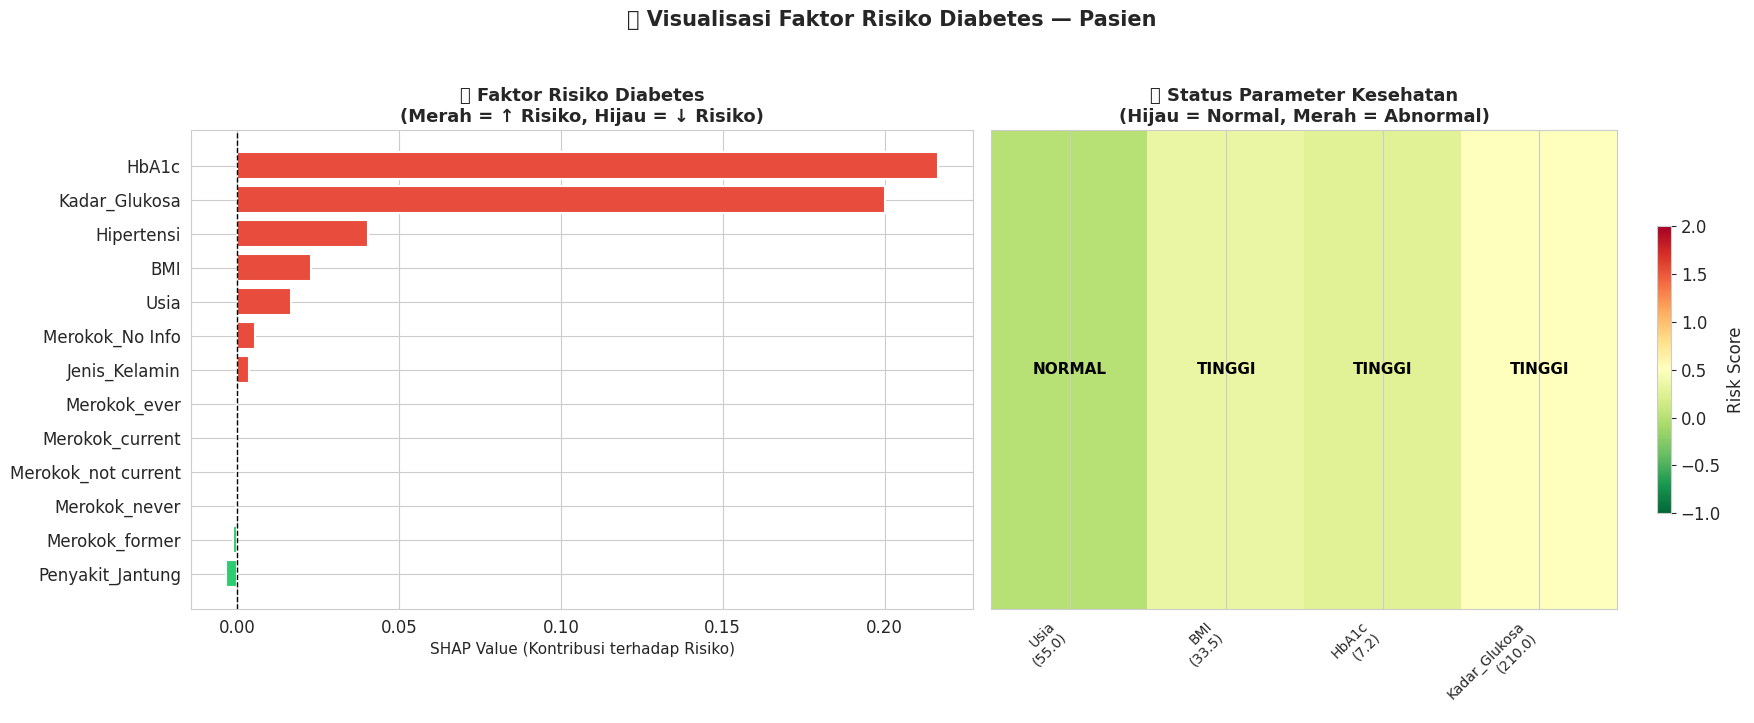


  ╔══════════════════════════════════════════════════════╗
  ║  OUTPUT 3: FAKTOR RISIKO (SHAP Analysis)           ║
  ╚══════════════════════════════════════════════════════╝
   🔴 HbA1c                     = 7.20       → MENINGKATKAN risiko (+0.2164)
   🔴 Kadar_Glukosa             = 210.00     → MENINGKATKAN risiko (+0.2002)
   🔴 Hipertensi                = 1.00       → MENINGKATKAN risiko (+0.0405)
   🔴 BMI                       = 33.50      → MENINGKATKAN risiko (+0.0227)
   🔴 Usia                      = 55.00      → MENINGKATKAN risiko (+0.0166)
   🔴 Merokok_No Info           = 0.00       → MENINGKATKAN risiko (+0.0054)
   🔴 Jenis_Kelamin             = 1.00       → MENINGKATKAN risiko (+0.0035)
   🟢 Penyakit_Jantung          = 0.00       → MENURUNKAN risiko (-0.0033)
   🟢 Merokok_former            = 0.00       → MENURUNKAN risiko (-0.0012)
   🟢 Merokok_never             = 0.00       → MENURUNKAN risiko (-0.0005)
   🟢 Merokok_not current       = 1.00       → MENURUNKAN risiko (-0.00

In [21]:
# ============================================================
# CELL 21: DEMO — Prediksi Pasien Baru
# ============================================================
print("=" * 70)
print("🏥 DEMO: PREDIKSI PASIEN BARU")
print("=" * 70)

# Contoh Pasien A — Risiko Tinggi
print("\n" + "─" * 70)
print("📋 PASIEN A — Profil Risiko Tinggi")
print("─" * 70)

# Buat dictionary fitur → nilai untuk kemudahan
pasien_a_dict = {}
for feat in feature_names:
    if feat == 'Jenis_Kelamin':
        pasien_a_dict[feat] = 1  # Male
    elif feat == 'Usia':
        pasien_a_dict[feat] = 55.0
    elif feat == 'Hipertensi':
        pasien_a_dict[feat] = 1
    elif feat == 'Penyakit_Jantung':
        pasien_a_dict[feat] = 0
    elif feat == 'BMI':
        pasien_a_dict[feat] = 33.5
    elif feat == 'HbA1c':
        pasien_a_dict[feat] = 7.2
    elif feat == 'Kadar_Glukosa':
        pasien_a_dict[feat] = 210
    elif 'current' in feat.lower():
        pasien_a_dict[feat] = 1  # Perokok aktif
    else:
        pasien_a_dict[feat] = 0  # Fitur merokok lainnya = 0

# Konversi ke list sesuai urutan feature_names
pasien_a_data = [pasien_a_dict[feat] for feat in feature_names]

print(f"   Jenis Kelamin    : Laki-laki")
print(f"   Usia             : 55 tahun")
print(f"   BMI              : 33.5 (Obesitas)")
print(f"   HbA1c            : 7.2% (Tinggi)")
print(f"   Kadar Glukosa    : 210 mg/dL (Tinggi)")
print(f"   Hipertensi       : Ya")
print(f"   Penyakit Jantung : Tidak")
print(f"   Riwayat Merokok  : Perokok Aktif")

hasil_a = prediksi_diabetes(
    data_pasien=pasien_a_data,
    model=best_rf,
    scaler_obj=scaler,
    feature_names_list=feature_names,
    shap_explainer=explainer_shap,
    X_train_data=X_train_resampled,
    threshold=FINAL_THRESHOLD,
    show_plot=True
)


──────────────────────────────────────────────────────────────────────
📋 PASIEN B — Profil Sehat
──────────────────────────────────────────────────────────────────────
   Jenis Kelamin    : Perempuan
   Usia             : 28 tahun
   BMI              : 22.1 (Normal)
   HbA1c            : 4.8% (Normal)
   Kadar Glukosa    : 95 mg/dL (Normal)
   Hipertensi       : Tidak
   Penyakit Jantung : Tidak
   Riwayat Merokok  : Tidak Pernah

══════════════════════════════════════════════════════════════════════
  🏥  LAPORAN PREDIKSI DIABETES — SISTEM AI DIAGNOSTIC
══════════════════════════════════════════════════════════════════════

  ╔══════════════════════════════════════════════════════╗
  ║  OUTPUT 1: STATUS PREDIKSI (Threshold = 0.1579)    ║
  ║  ✅ SEHAT (Tidak Berisiko Diabetes)                   ║
  ╚══════════════════════════════════════════════════════╝

  ╔══════════════════════════════════════════════════════╗
  ║  OUTPUT 2: SKOR PROBABILITAS (CONFIDENCE)           ║
  ║            

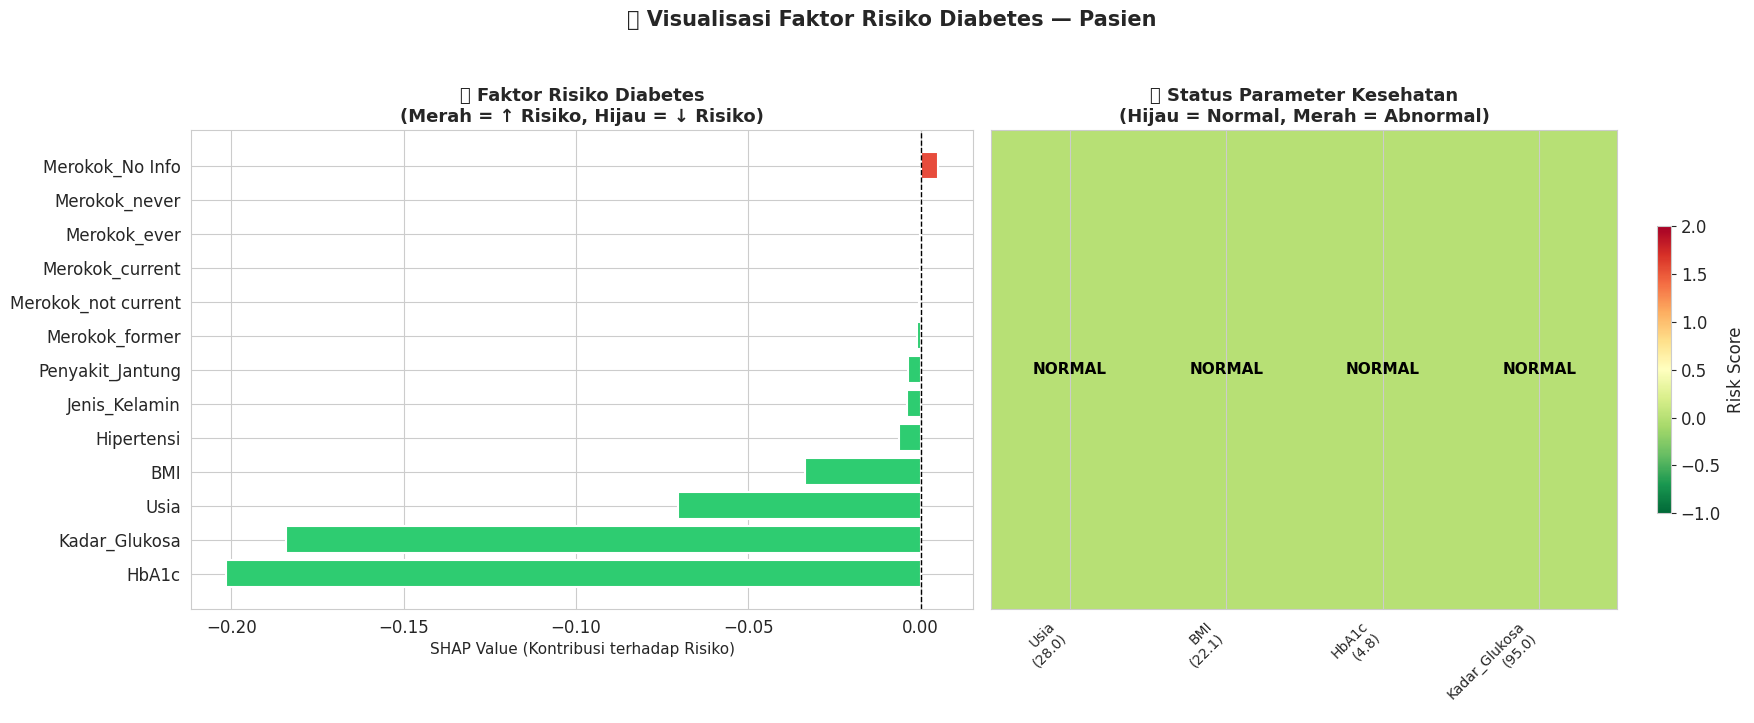


  ╔══════════════════════════════════════════════════════╗
  ║  OUTPUT 3: FAKTOR RISIKO (SHAP Analysis)           ║
  ╚══════════════════════════════════════════════════════╝
   🟢 HbA1c                     = 4.80       → MENURUNKAN risiko (-0.2015)
   🟢 Kadar_Glukosa             = 95.00      → MENURUNKAN risiko (-0.1841)
   🟢 Usia                      = 28.00      → MENURUNKAN risiko (-0.0703)
   🟢 BMI                       = 22.10      → MENURUNKAN risiko (-0.0336)
   🟢 Hipertensi                = 0.00       → MENURUNKAN risiko (-0.0063)
   🔴 Merokok_No Info           = 0.00       → MENINGKATKAN risiko (+0.0049)
   🟢 Jenis_Kelamin             = 0.00       → MENURUNKAN risiko (-0.0040)
   🟢 Penyakit_Jantung          = 0.00       → MENURUNKAN risiko (-0.0037)
   🟢 Merokok_former            = 0.00       → MENURUNKAN risiko (-0.0010)
   🟢 Merokok_not current       = 0.00       → MENURUNKAN risiko (-0.0005)
   🔴 Merokok_never             = 1.00       → MENINGKATKAN risiko (+0.0004)
   🟢 M

In [22]:
# Contoh Pasien B — Profil Sehat
print("\n" + "─" * 70)
print("📋 PASIEN B — Profil Sehat")
print("─" * 70)

pasien_b_dict = {}
for feat in feature_names:
    if feat == 'Jenis_Kelamin':
        pasien_b_dict[feat] = 0  # Female
    elif feat == 'Usia':
        pasien_b_dict[feat] = 28.0
    elif feat == 'Hipertensi':
        pasien_b_dict[feat] = 0
    elif feat == 'Penyakit_Jantung':
        pasien_b_dict[feat] = 0
    elif feat == 'BMI':
        pasien_b_dict[feat] = 22.1
    elif feat == 'HbA1c':
        pasien_b_dict[feat] = 4.8
    elif feat == 'Kadar_Glukosa':
        pasien_b_dict[feat] = 95
    elif 'never' in feat.lower():
        pasien_b_dict[feat] = 1  # Tidak pernah merokok
    else:
        pasien_b_dict[feat] = 0

pasien_b_data = [pasien_b_dict[feat] for feat in feature_names]

print(f"   Jenis Kelamin    : Perempuan")
print(f"   Usia             : 28 tahun")
print(f"   BMI              : 22.1 (Normal)")
print(f"   HbA1c            : 4.8% (Normal)")
print(f"   Kadar Glukosa    : 95 mg/dL (Normal)")
print(f"   Hipertensi       : Tidak")
print(f"   Penyakit Jantung : Tidak")
print(f"   Riwayat Merokok  : Tidak Pernah")

hasil_b = prediksi_diabetes(
    data_pasien=pasien_b_data,
    model=best_rf,
    scaler_obj=scaler,
    feature_names_list=feature_names,
    shap_explainer=explainer_shap,
    X_train_data=X_train_resampled,
    threshold=FINAL_THRESHOLD,
    show_plot=True
)

In [23]:
# ============================================================
# CELL 22: RINGKASAN AKHIR SISTEM
# ============================================================
print("\n" + "═" * 70)
print("  📊  RINGKASAN AKHIR SISTEM PREDIKSI DIABETES")
print("═" * 70)
print(f"""
  📌 DATASET:
     • Sumber      : Kaggle Diabetes Prediction Dataset
     • Total Data  : {len(df):,} pasien
     • Fitur       : {len(feature_names)} variabel klinis

  ⚙️ PREPROCESSING:
     • Data Cleaning  : Imputasi nilai 0 tidak valid dengan Median
     • Encoding       : Label Encoding (Gender) + One-Hot (Smoking)
     • Scaling        : StandardScaler (fit pada training only)
     • SMOTE          : Diterapkan HANYA pada data latih (50:50)

  🌲 MODEL:
     • Algoritma      : Random Forest Classifier
     • Tuning         : RandomizedSearchCV (50 iter × 5-Fold CV)
     • Scoring        : Recall (Prioritas Medis)
     • Best Params    : {random_search.best_params_}

  🎚️ THRESHOLD TUNING:
     • Metode          : Youden's J Statistic (max TPR - FPR)
     • Threshold Default: 0.50
     • Threshold Optimal: {optimal_threshold:.4f}
     • Threshold Final  : {FINAL_THRESHOLD:.4f}

  📊 PERFORMA (Data Uji — Threshold = {FINAL_THRESHOLD:.4f}):
     • Accuracy       : {accuracy:.4f} ({accuracy*100:.2f}%)
     • Precision      : {precision:.4f} ({precision*100:.2f}%)
     • ★ RECALL       : {recall:.4f} ({recall*100:.2f}%)
     • F1-Score       : {f1:.4f} ({f1*100:.2f}%)
     • ROC-AUC        : {roc_auc:.4f} ({roc_auc*100:.2f}%)

  🔍 XAI (Explainability):
     • Global         : SHAP Summary Plot (Feature Ranking)
     • Local          : SHAP Waterfall + LIME (Per Pasien)

  🏥 OUTPUT SISTEM (4 Deliverables):
     1. Status Prediksi Biner (Sehat / Berisiko Diabetes)
     2. Skor Probabilitas (Confidence Score)
     3. Visualisasi Faktor Risiko (SHAP/LIME)
     4. Rekomendasi Medis Dasar (Berdasarkan Feature Importance)
""")

print("  ✅ Sistem siap digunakan sebagai alat skrining awal diabetes!")
print("  ⚠️  Hasil skrining harus dikonfirmasi oleh tenaga medis profesional.")
print("═" * 70)


══════════════════════════════════════════════════════════════════════
  📊  RINGKASAN AKHIR SISTEM PREDIKSI DIABETES
══════════════════════════════════════════════════════════════════════

  📌 DATASET:
     • Sumber      : Kaggle Diabetes Prediction Dataset
     • Total Data  : 96,128 pasien
     • Fitur       : 13 variabel klinis

  ⚙️ PREPROCESSING:
     • Data Cleaning  : Imputasi nilai 0 tidak valid dengan Median
     • Encoding       : Label Encoding (Gender) + One-Hot (Smoking)
     • Scaling        : StandardScaler (fit pada training only)
     • SMOTE          : Diterapkan HANYA pada data latih (50:50)

  🌲 MODEL:
     • Algoritma      : Random Forest Classifier
     • Tuning         : RandomizedSearchCV (50 iter × 5-Fold CV)
     • Scoring        : Recall (Prioritas Medis)
     • Best Params    : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'criterion': 'entropy', 'class_weight': 'balanced'}

  🎚️ THRESHOLD TUNI